# **Subjektivní analýza novinových článků**

Tématem projektu do Text Miningu jsme si zvolili **Subjektivní analýzu novinových článků**.

Cílem je zjistit zda dokážeme čerpat z novinových článků informace o zaujatosti autora. Druhotným cílem je znázornit možné cesty a variace jak výsledku dosáhnout nebo jej vylepšit pomocí technik používaných v oboru text miningu.

### Stažení potřebných knihoven.
Nechali jsme si doporučit knihovny hodící se k extrahování informací z textu a webovému scrapingu. Mimo to jsme použili doporučený Hugging Face z cvičení z důvodu obsahování pokročilých modelů.
Jsou jimi:
- **newspaper3k**: Knihovna pro stahování, parsování a analýzu novinových článků a blogů z webu.
- **lxml_html_clean**: Nástroj pro čištění HTML dokumentů, odstranění nepotřebných tagů a atributů.
- **textblob**: Knihovna pro zpracování textu, která poskytuje jednoduché API pro běžné úlohy NLP, jako je značkování části řeči, extrakce podstatných jmen, analýza sentimentu a další.
- **transformers**: Knihovna od Hugging Face pro práci s nejmodernějšími předtrénovanými modely (jako BERT, GPT-2 atd.) pro různé NLP úlohy.
- **torch**: Open-source knihovna pro strojové učení, která se používá pro tvorbu a trénování neuronových sítí.
- **ufal.udpipe**: Nástroj pro zpracování přirozeného jazyka (NLP), který poskytuje tokenizaci, lemmatizaci, značkování části řeči (POS tagging) a syntaktickou analýzu pro mnoho jazyků, včetně češtiny.
- **requests**: Jednoduchá HTTP knihovna pro Python, která umožňuje snadno odesílat HTTP požadavky.

In [1]:
!pip install newspaper3k lxml_html_clean textblob transformers torch ufal.udpipe requests


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 1. & 2. Sběr a extrakce textu z článků
Pro scrapování lze použít knihovna `newspaper3k`, která automaticky detekuje text článku, autora i datum publikace. Bohužel pro české články to ne vždy platí a tak je třeba navést tuto knihovnu ručně na tagy ve stránce.

**Deginice funkce**

In [2]:
from newspaper import Article, build, Config
import requests
from bs4 import BeautifulSoup
import json

def get_articles_from_url(base_url, num_articles=None):
    config = Config()
    config.browser_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
    config.request_timeout = 30

    print(f"Pokouším se stáhnout články z: {base_url}")
    try:
        paper = build(base_url, config=config, memoize_articles=False)
        print(f"Nalezeno {len(paper.articles)} potenciálních článků.")
    except Exception as e:
        print(f"Chyba při načítání stránek nebo budování zdroje: {e}")
        return []

    articles_data = []
    filtered_articles = [article_obj for article_obj in paper.articles if '/clanek/' in article_obj.url]
    print(f"Po filtrování podle '/clanek/' zbývá {len(filtered_articles)} potenciálních článků.")

    for i, article_obj in enumerate(filtered_articles):
        if num_articles is not None and i >= num_articles:
            break
        try:
            article = Article(article_obj.url, config=config)
            article.download()
            article.parse()

            soup = None
            if article.html:
                soup = BeautifulSoup(article.html, 'lxml')

            # --- EXTRAKCE TITULKU ---
            if not article.title and soup:
                og_title = soup.find('meta', property='og:title')
                if og_title and og_title.get('content'):
                    article.title = og_title['content'].strip()
                elif soup.title:
                    article.title = soup.title.get_text(strip=True).replace(' - Seznam Zprávy', '')
                else:
                    h1_tag = soup.find('h1')
                    if h1_tag:
                        article.title = h1_tag.get_text(strip=True)

            # --- EXTRAKCE AUTORA A DATA PUBLIKACE (PŘES JSON-LD) ---
            authors_list = article.authors
            publish_date = None # Začínáme s None, chceme ideálně přesný ISO string z HTML

            if soup:
                for script in soup.find_all('script', type='application/ld+json'):
                    try:
                        data = json.loads(script.string)
                        if isinstance(data, list):
                            data = data[0] # Vezmeme první prvek, pokud jde o seznam

                        # Hledáme schema.org typy pro články
                        if isinstance(data, dict) and data.get('@type') in ['NewsArticle', 'Article', 'ReportageNewsArticle']:

                            # Vytáhneme datum
                            if not publish_date and data.get('datePublished'):
                                publish_date = data.get('datePublished')

                            # Vytáhneme autory
                            if not authors_list:
                                author_data = data.get('author')
                                if isinstance(author_data, list):
                                    authors_list = [a.get('name') for a in author_data if isinstance(a, dict) and a.get('name')]
                                elif isinstance(author_data, dict) and author_data.get('name'):
                                    authors_list = [author_data.get('name')]
                    except (json.JSONDecodeError, TypeError, AttributeError):
                        continue

            # --- ZÁLOŽNÍ EXTRAKCE DATA PUBLIKACE (Meta tagy) ---
            if not publish_date and soup:
                # Nejspolehlivější meta tag pro zpravodajské weby
                meta_time = soup.find('meta', property='article:published_time')
                if meta_time and meta_time.get('content'):
                    publish_date = meta_time['content'].strip()
                else:
                    # Klasický schema.org meta tag
                    meta_date = soup.find('meta', attrs={'itemprop': 'datePublished'})
                    if meta_date and meta_date.get('content'):
                        publish_date = meta_date['content'].strip()

            # Fallback na původní knihovnu newspaper3k (kdyby všechno ostatní selhalo)
            if not publish_date and article.publish_date:
                # Newspaper3k často vrací 'datetime' objekt. Převedeme ho na text, ať je to konzistentní
                publish_date = article.publish_date.strftime('%Y-%m-%dT%H:%M:%S')

            # --- ZÁLOŽNÍ EXTRAKCE AUTORA (Meta tag) ---
            if not authors_list and soup:
                meta_author = soup.find('meta', attrs={'name': 'author'})
                if meta_author and meta_author.get('content'):
                    authors_list = [meta_author['content'].strip()]


            # --- UKLÁDÁNÍ VÝSLEDKŮ ---
            if article.text and article.title:
                articles_data.append({
                    'url': article.url,
                    'title': article.title,
                    'authors': authors_list,
                    'publish_date': publish_date, # Nyní spolehlivě v ISO 8601 formátu
                    'text': article.text
                })
                print(f"Stažen článek {i+1}: {article.title} | Datum: {publish_date} | Autoři: {', '.join(authors_list) if authors_list else 'Neznámý'}")
            else:
                print(f"Článek {i+1} z {article_obj.url} neobsahuje text nebo titulek, přeskočen.")

        except Exception as e:
            print(f"Chyba při stahování nebo parsování článku z {article_obj.url}: {e}")
            continue

    return articles_data

**Spuštění funkce** pro scrapování článků z www.seznamzpravy.cz/

- Článek od článku dochází k přehlédnutí nadpisu a tím dojde k zahození článků. Tato chybavost nám ale nevadí, vždy můžem zvednout počet článků, kdybychom potřebovali více textu na dedukci.
- Z článků extrahujeme [odkaz, název článku, autora a datum publikace]

In [3]:
import pandas as pd

# For example, to download 10 articles:
num_articles_to_download = 20
seznam_zpravy_articles = get_articles_from_url("https://www.seznamzpravy.cz/", num_articles=num_articles_to_download)

if seznam_zpravy_articles:
    articles_df = pd.DataFrame(seznam_zpravy_articles)
    display(articles_df[['url', 'title', 'authors', 'publish_date']].head(num_articles_to_download))
else:
    print("Nebyly staženy žádné články nebo došlo k chybě.")

Pokouším se stáhnout články z: https://www.seznamzpravy.cz/
Nalezeno 111 potenciálních článků.
Po filtrování podle '/clanek/' zbývá 102 potenciálních článků.
Článek 1 z https://www.seznamzpravy.cz/clanek/zdravi-plus-mapa-ortopedu-ordinace-praha-vsechny-kraje-301728 neobsahuje text nebo titulek, přeskočen.
Článek 2 z https://www.seznamzpravy.cz/clanek/domaci-kauzy-policejni-navsteva-ustecke-kliniky-detektivove-opet-cili-na-podezrele-operace-306097 neobsahuje text nebo titulek, přeskočen.
Stažen článek 3: Berou sto tisíc, je jim přes 30 a žijí ve spolubydlení. Bude jich víc | Datum: 2026-05-14T05:00:00.000Z | Autoři: Markéta Bidrmanová
Stažen článek 4: Kdy jsou opravdu potřeba antibiotika a jak přesně působí | Datum: 2026-05-14T06:00:00.000Z | Autoři: Lucie Frydecká
Stažen článek 5: „Prsty ukazuje šest.“ Policie natočila, jak primář zařizuje posudky za peníze | Datum: 2026-05-14T12:01:02.000Z | Autoři: Jakub Mikel, Kateřina Gruntová
Článek 6 z https://www.seznamzpravy.cz/clanek/domaci-po

,url,title,authors,publish_date
0,https://www.seznamzpravy.cz/clanek/audio-podca...,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",[Markéta Bidrmanová],2026-05-14T05:00:00.000Z
1,https://www.seznamzpravy.cz/clanek/audio-podca...,Kdy jsou opravdu potřeba antibiotika a jak pře...,[Lucie Frydecká],2026-05-14T06:00:00.000Z
2,https://www.seznamzpravy.cz/clanek/domaci-kauz...,"„Prsty ukazuje šest.“ Policie natočila, jak pr...","[Jakub Mikel, Kateřina Gruntová]",2026-05-14T12:01:02.000Z
3,https://www.seznamzpravy.cz/clanek/domaci-cest...,"Češtinu kazí především politici a média, kriti...",[Fórum čtenářů],2026-05-14T09:30:00.000Z
4,https://www.seznamzpravy.cz/clanek/domaci-jede...,"Jeden z Babišovy party padl, druhý přichází. Č...",[David Klimeš],2026-05-14T05:30:00.000Z
5,https://www.seznamzpravy.cz/clanek/domaci-zivo...,Proočkovanost proti covidu se dramaticky propa...,[Josef Mačí],2026-05-14T04:20:00.000Z
6,https://www.seznamzpravy.cz/clanek/ekonomika-f...,Schillerové protiinflační dluhopisy se vrací,[Markéta Bidrmanová],2026-05-14T11:22:53.000Z
7,https://www.seznamzpravy.cz/clanek/ekonomika-b...,Železniční megatendr vrcholí. Vyhrát může jedi...,[Jan Richter],2026-05-14T07:45:00.000Z
8,https://www.seznamzpravy.cz/clanek/audio-podca...,"Měli bychom změnit zákon, aby na dotace měl ná...",[Marie Bastlová],2026-05-14T10:49:31.000Z
9,https://www.seznamzpravy.cz/clanek/domaci-poli...,"Střízlivá Sněmovna. Je tu návrh, aby poslanci ...",[Lucie Stuchlíková],2026-05-14T07:59:36.000Z


### 3. Předzpracování textu
Úspěšně jsme extrahovali potřebná data pro analýzu článků. V této části preprocesujeme data pomocí zmíňených postupů z vyuky. Snažíme se text očistit takovým způsobem, aby jsme se zbavili nepotřebných informací a zvýšili užitnou hodnotu pro náš cíl.
Postupy které jsme zvolili pro náš cíl jsou:
1.  **Převod na malá písmena**: Sjednotí všechna slova, takže "Slovo" a "slovo" jsou považovány za stejné. To je klíčové pro správné počítání frekvence slov a pro konsistentní analýzu.
2.  **Odstranění interpunkce**: Interpunkční znaménka často nepřinášejí sémantický význam pro analýzu textu a mohou zkreslovat výsledky (např. "slovo." vs. "slovo"). Jejich odstranění zjednodušuje text a zlepšuje rozpoznávání slov.
3.  **Odstranění číslic** <--- kontroverzní krok: Číslice (např. data, množství) mohou v některých kontextech být důležité, ale pro analýzu zaujatosti nebo sémantickou podobnost často představují šum.
4.  **Odstranění stop slov**: Stop slova (jako "a", "je", "na") jsou velmi častá, ale obvykle nepřinášejí mnoho významových informací. Jejich odstranění snižuje dimenzionalitu dat a pomáhá zaměřit se na důležitější slova, která lépe odrážejí obsah textu.
5.  **Odstranění přebytečných mezer**: Vícenásobné mezery mohou vzniknout po odstranění jiných prvků a mohou způsobovat problémy při tokenizaci nebo dalších fázích zpracování. Jejich sjednocení na jednu mezeru udržuje text čistý a formátovaný.

**Definice funkcí:**

In [4]:
import re
import string

# Česká stop slova - rozšířený seznam
czech_stop_words = set([
    "a", "aby", "ahoj", "ale", "anebo", "ani", "ano", "asi", "ať", "bez", "bude", "budete", "budeme", "budeš", "budou", "by", "byl", "byla", "byli", "bylo", "být", "či", "co", "což", "další", "díky", "dle", "dnes", "do", "dobrý", "docela", "dost", "eventuálně", "furt", "hodně", "já", "jak", "jako", "je", "jeden", "jednak", "jednou", "jej", "jejich", "její", "jemu", "jen", "jenom", "jestli", "jestliže", "jež", "ji", "jinak", "jiný", "již", "jí", "jsem", "jsi", "jsme", "jsou", "jste", "k", "kam", "kde", "kdo", "kdy", "když", "ke", "kolik", "kromě", "která", "které", "který", "kteří", "ktera", "kterou", "kterými", "ktery", "kvůli", "ma", "má", "mají", "mám", "máme", "máte", "mezi", "mě", "mně", "mnohý", "možná", "moji", "moja", "moje", "my", "na", "nad", "nám", "například", "náš", "naši", "naše", "ně", "nějaký", "někde", "někdo", "neměli", "není", "než", "nic", "nich", "ním", "niz", "nové", "nový", "o", "od", "on", "ona", "ono", "oni", "ony", "pak", "po", "pod", "podle", "pokud", "pouze", "právě", "pro", "proč", "prosím", "první", "před", "přes", "při", "přitom", "ráda", "se", "si", "sice", "spíše", "sta", "stále", "své", "svou", "svůj", "svých", "tak", "taky", "tam", "tamhle", "tato", "teď", "tehdy", "ten", "tento", "této", "tím", "tipy", "to", "tohle", "toho", "toto", "třeba", "tu", "tuto", "ty", "týden", "už", "v", "vám", "váš", "vaše", "ve", "velmi", "vedle", "více", "vlastně", "však", "všechno", "vy", "z", "za", "zatímco", "zde", "ze", "že", "či", "aby", "kdyz", "nez", "pokud", "takze", "taky", "uz", "vam", "vas", "byt", "coz", "ktera", "kterej", "kteri", "ktere", "ktery", "muj", "muze", "mych", "neznamy", "nic", "podle", "pres", "proto", "rovnez", "sice", "tak", "taky", "ten", "to", "tento", "treba", "uz", "vas", "vice", "vubec", "za", "zase", "zde", "ze"
])

def to_lowercase(text):
    """Převede text na malá písmena."""
    return text.lower()

def remove_punctuation(text):
    """Odstraní interpunkci z textu."""
    return text.translate(str.maketrans('', '', string.punctuation))

def remove_numbers(text):
    """Odstraní číslice z textu."""
    return re.sub(r'\d+', '', text)

def remove_stopwords(text, stop_words):
    """Odstraní stop slova z textu."""
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

def remove_extra_whitespace(text):
    """Odstraní vícenásobné mezery a ořízne text."""
    return re.sub(r'\s+', ' ', text).strip()

def preprocess_text(text, stop_words):
    """Provede kompletní předzpracování textu."""
    text = to_lowercase(text)
    text = remove_punctuation(text)
    text = remove_numbers(text)
    text = remove_stopwords(text, stop_words)
    text = remove_extra_whitespace(text)
    return text

**Spuštění funkcí:**

In [5]:
# Aplikujeme předzpracování na texty v DataFrame
if 'articles_df' in locals() and not articles_df.empty:
    articles_df['cleaned_text'] = articles_df['text'].apply(lambda x: preprocess_text(x, czech_stop_words))
    print("Předzpracování textu dokončeno. Zde je srovnání původního a vyčištěného textu pro první 3 články:")
    for i in range(min(3, len(articles_df))):
        print(f"\n--- Článek {i+1} ---")
        print(f"Původní: {articles_df.loc[i, 'text'][:300]}...") # Zobrazíme jen prvních 300 znaků
        print(f"Vyčištěný: {articles_df.loc[i, 'cleaned_text'][:300]}...")
else:
    print("DataFrame 'articles_df' neexistuje nebo je prázdný. Ujistěte se, že jste stáhli články dříve.")

Předzpracování textu dokončeno. Zde je srovnání původního a vyčištěného textu pro první 3 články:

--- Článek 1 ---
Původní: Spolubydlení už není výsadou studentů. Do sdílených bytů dnes míří i dobře vydělávající manažeři, kteří by si ještě nedávno koupili vlastní nemovitost. Investoři rozdělí byt klidně na čtyři jednotky, a tím zvýší výnosy.

Ještě před pár lety bylo spolubydlení určené hlavně pro studenty. Dneska ale v ...
Vyčištěný: spolubydlení výsadou studentů sdílených bytů míří i dobře vydělávající manažeři ještě nedávno koupili vlastní nemovitost investoři rozdělí klidně čtyři jednotky zvýší výnosy ještě pár lety spolubydlení určené hlavně studenty dneska pokojích dvanáct patnáct i osmnáct tisíc korun bydlí ajťáci manažeři...

--- Článek 2 ---
Původní: Antibiotika často užíváme špatně. Není potřeba je brát vždy, když se objeví zelená rýma nebo výtok z oka. A vyhýbat bychom se měli hlavně těm, která máme nejraději – rychlým třídenním. Rozhodně nejsou šetrná.

Třídenní antibiotik

### 4. Part-of-Speech Tagging (POS Tagging) pomocí Stanza
Je třeba označit slova jejich význami, aby jsme měli větší pravděpodobnost při analýze, že správně pochopíme kontext. K tomu se nám skvěle hodí POS tagging z knihovny Stanza.

K tomu, ale musíme stáhnout jejích natrénovaný model X verze ručně z webu a naimportovat jej pro naše užití.

Stanze si při POS taggingu provádí **tokenizaci, lemmatizaci a nakonec zmíněný POS** tagging sama.

**Import Stanzy:**

In [6]:
!pip install stanza


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


**Stažení jejich modelu pro český jazyk:**

In [7]:
import stanza
import pandas as pd

# Stáhneme český model (pokud ještě není stažen)
stanza.download('cs')

# Inicializace pipeline pro češtinu
nlp = stanza.Pipeline('cs', processors='tokenize,lemma,pos')

def stanza_process_text(text):
    """Provede analýzu textu pomocí Stanza a vrátí POS tagy, lemmata a přídavná jména."""
    if not text or pd.isna(text):
        return [], "", []

    doc = nlp(text)
    pos_tags = []
    lemmas = []
    adjectives = []

    for sentence in doc.sentences:
        for word in sentence.words:
            pos_tags.append((word.text, word.upos))
            lemmas.append(word.lemma)
            if word.upos == 'ADJ':
                adjectives.append(word.lemma)

    return pos_tags, " ".join(lemmas), adjectives

if 'articles_df' in locals() and not articles_df.empty:
    print("Provádím analýzu textu pomocí Stanza (to může trvat déle)... ")

    # Aplikujeme Stanza na vyčištěný text
    results = articles_df['cleaned_text'].apply(stanza_process_text)

    # Uložení výsledků do DataFrame
    articles_df['pos_tags'] = [res[0] for res in results]
    articles_df['lemmatized_text'] = [res[1] for res in results]
    articles_df['adjectives_only'] = [res[2] for res in results]

    print("Analýza dokončena.")
    display(articles_df[['title', 'pos_tags', 'lemmatized_text']].head(5))
else:
    print("DataFrame 'articles_df' neexistuje nebo je prázdný.")

/opt/homebrew/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-14 15:06:40 INFO: Downloaded file to /Users/student/Library/Caches/stanza/1.11.0/resources/resources.json
2026-05-14 15:06:40 INFO: Downloading default packages for language: cs (Czech) ...
2026-05-14 15:06:40 INFO: File exists: /Users/student/Library/Caches/stanza/1.11.0/resources/cs/default.zip
2026-05-14 15:06:41 INFO: Finished downloading models and saved to /Users/student/Library/Caches/stanza/1.11.0/resources
2026-05-14 15:06:41 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-05-14 15:06:41 INFO: Downloaded file to /Users/student/Library/Caches/stanza/1.11.0/resources/resources.js

Provádím analýzu textu pomocí Stanza (to může trvat déle)... 
Analýza dokončena.


,title,pos_tags,lemmatized_text
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...","[(spolubydlení, NOUN), (výsadou, NOUN), (stude...",spolubydlení výsada student sdílený byt mířit ...
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,"[(antibiotika, NOUN), (často, ADV), (užíváme, ...",antibiotikum často užívat špatně potřeba brát ...
2,"„Prsty ukazuje šest.“ Policie natočila, jak pr...","[(boj, NOUN), (stomilionovou, ADJ), (firmu, NO...",boj stomilionový firma pokus získání rodinný d...
3,"Češtinu kazí především politici a média, kriti...","[(angličtina, NOUN), (proniká, VERB), (profesn...",angličtina pronikat profesní i každodenní komu...
4,"Jeden z Babišovy party padl, druhý přichází. Č...","[(konec, NOUN), (režimu, NOUN), (viktora, PROP...",konec režim viktor orbán vypadat bizarní reali...


______________________________________________________


### 6. Analýza TF-IDF (Term Frequency-Inverse Document Frequency)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

if 'articles_df' in locals() and not articles_df.empty:
    # Inicializace TF-IDF vektorizéru
    # Použijeme vyčištěný text, který už nemá stop slova a interpunkci
    tfidf = TfidfVectorizer(max_features=1000)
    tfidf_matrix = tfidf.fit_transform(articles_df['cleaned_text'])

    # Získání názvů vlastností (slov)
    feature_names = tfidf.get_feature_names_out()

    def get_top_tf_idf_words(row_index, top_n=10):
        """Vrátí top N slov s nejvyšším TF-IDF skóre pro daný řádek (článek)."""
        row = tfidf_matrix.getrow(row_index).toarray().flatten()
        top_indices = row.argsort()[-top_n:][::-1]
        return [(feature_names[i], round(row[i], 4)) for i in top_indices if row[i] > 0]

    print("Top slova podle TF-IDF pro první 3 články:\n")
    for i in range(min(3, len(articles_df))):
        print(f"--- Článek {i+1}: {articles_df.loc[i, 'title']} ---")
        top_words = get_top_tf_idf_words(i)
        for word, score in top_words:
            print(f"  {word}: {score}")
        print()
else:
    print("Dataframe 'articles_df' neexistuje nebo je prázdný.")

Top slova podle TF-IDF pro první 3 články:

--- Článek 1: Berou sto tisíc, je jim přes 30 a žijí ve spolubydlení. Bude jich víc ---
  spolubydlení: 0.3861
  bydlení: 0.3089
  fohler: 0.3089
  tisíc: 0.2331
  pavel: 0.1665
  čtyři: 0.1665
  bytě: 0.1545
  bytů: 0.1545
  nájemníky: 0.1545
  korun: 0.1453

--- Článek 2: Kdy jsou opravdu potřeba antibiotika a jak přesně působí ---
  antibiotika: 0.4087
  bezdíčková: 0.2973
  lékařka: 0.2601
  penicilin: 0.2601
  dovolenou: 0.1858
  pacienti: 0.1858
  antibiotiky: 0.1486
  lékaři: 0.1486
  cyril: 0.1486
  ludmila: 0.1486

--- Článek 3: „Prsty ukazuje šest.“ Policie natočila, jak primář zařizuje posudky za peníze ---
  posudek: 0.3874
  muž: 0.2246
  vyšetřování: 0.2246
  rodinného: 0.2246
  tichý: 0.2246
  tichého: 0.2246
  policejní: 0.1937
  policie: 0.1937
  měl: 0.1586
  vojenské: 0.1498



### 7. Extrakce hlavních témat (postavená pouze na TF-IDF a 1-grammech)
Pomocí dříve vypočítaného TF-IDF skóre nyní extrahujeme pro každý článek několik nejvýznamnějších slov, která slouží jako identifikátory témat.

In [9]:
if 'articles_df' in locals() and not articles_df.empty:
    def extract_article_topics(row_index, top_n=5):
        """Vrátí řetězec top N klíčových slov jako téma."""
        top_words_with_scores = get_top_tf_idf_words(row_index, top_n=top_n)
        return ", ".join([word for word, score in top_words_with_scores])

    # Aplikujeme na všechny články
    articles_df['top_keywords'] = [extract_article_topics(i) for i in range(len(articles_df))]

    print("Ukázka extrahovaných témat pro články:")
    display(articles_df[['title', 'top_keywords']].head(10))
else:
    print("Dataframe 'articles_df' neexistuje.")

Ukázka extrahovaných témat pro články:


,title,top_keywords
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...","spolubydlení, bydlení, fohler, tisíc, pavel"
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,"antibiotika, bezdíčková, lékařka, penicilin, d..."
2,"„Prsty ukazuje šest.“ Policie natočila, jak pr...","posudek, muž, vyšetřování, rodinného, tichý"
3,"Češtinu kazí především politici a média, kriti...","jazyk, český, slova, učí, čeština"
4,"Jeden z Babišovy party padl, druhý přichází. Č...","nyní, babiš, eu, okno, le"
5,Proočkovanost proti covidu se dramaticky propa...,"onemocnění, procent, proti, trendem, riziko"
6,Schillerové protiinflační dluhopisy se vrací,"dluhopisů, splatnosti, dluhopis, výnos, míní"
7,Železniční megatendr vrcholí. Vyhrát může jedi...,"tendru, dopravce, vlaky, zadavatel, borecký"
8,"Měli bychom změnit zákon, aby na dotace měl ná...","samozřejmě, dotace, protože, zákon, byly"
9,"Střízlivá Sněmovna. Je tu návrh, aby poslanci ...","vykázat, nesmí, jednacího, návrhu, práci"


### 6-a. Zpřesnění témat (Lemmatizace + Bigramy)
Nyní provedeme proces znovu, ale tentokrát:
1. **Zlemmatizujeme** texty pomocí UDPipe (převedeme slova na základní tvary).
2. Nastavíme TF-IDF tak, aby hledalo i **dvouslovná spojení** (ngram_range=(1, 2)).

In [10]:
import ufal.udpipe

def get_lemmas(tokens, pipeline):
    """Extrahuje lemmata z tokenů pomocí UDPipe."""
    text = " ".join(tokens)
    processed_text = pipeline.process(text)
    conllu_input = ufal.udpipe.InputFormat.newInputFormat("conllu")
    conllu_input.setText(processed_text)

    sentence = ufal.udpipe.Sentence()
    lemmas = []
    while conllu_input.nextSentence(sentence):
        for token in sentence.words:
            if token.id > 0:
                lemmas.append(token.lemma.lower())
    return " ".join(lemmas)

if "articles_df" in locals() and not articles_df.empty:
    if "lemmatized_text" in articles_df.columns:
        print("Lemmatizace již proběhla pomocí Stanza, přeskakuji UDPipe krok.")
    else:
        try:
            print("Provádím lemmatizaci textů pomocí UDPipe...")
            articles_df["lemmatized_text"] = articles_df["cleaned_text"].str.split().apply(
                lambda x: get_lemmas(x, process_pipeline)
            )
            print("Lemmatizace dokončena.")
        except Exception as e:
            print(f"Chyba při UDPipe lemmatizaci: {e}")


Lemmatizace již proběhla pomocí Stanza, přeskakuji UDPipe krok.


In [11]:
if 'lemmatized_text' in articles_df.columns:
    # Vektorizér s podporou dvouslovných spojení (ngram_range)
    tfidf_refined = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
    tfidf_matrix_refined = tfidf_refined.fit_transform(articles_df['lemmatized_text'])
    feature_names_refined = tfidf_refined.get_feature_names_out()

    def get_refined_topics(row_index, top_n=5):
        row = tfidf_matrix_refined.getrow(row_index).toarray().flatten()
        top_indices = row.argsort()[-top_n:][::-1]
        return ", ".join([feature_names_refined[i] for i in top_indices if row[i] > 0])

    articles_df['top_keywords_refined'] = [get_refined_topics(i) for i in range(len(articles_df))]

    print("Srovnání: Původní vs. Zpřesněná témata (s lemmatizací a frázemi):")
    display(articles_df[['title', 'top_keywords', 'top_keywords_refined']].head(10))

Srovnání: Původní vs. Zpřesněná témata (s lemmatizací a frázemi):


,title,top_keywords,top_keywords_refined
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...","spolubydlení, bydlení, fohler, tisíc, pavel","byt, nájemník, spolubydlení, bydlení, fohler"
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,"antibiotika, bezdíčková, lékařka, penicilin, d...","antibiotikum, pacient, lékař, bezdíčkový, lékařka"
2,"„Prsty ukazuje šest.“ Policie natočila, jak pr...","posudek, muž, vyšetřování, rodinného, tichý","tichý, posudek, muž, policie, detektiv"
3,"Češtinu kazí především politici a média, kriti...","jazyk, český, slova, učí, čeština","jazyk, čeština, učit, mluvit, psát"
4,"Jeden z Babišovy party padl, druhý přichází. Č...","nyní, babiš, eu, okno, le","evropský, babiš, nyní, politický, rozpočet"
5,Proočkovanost proti covidu se dramaticky propa...,"onemocnění, procent, proti, trendem, riziko","covid, onemocnění, procento, proti, odborník"
6,Schillerové protiinflační dluhopisy se vrací,"dluhopisů, splatnosti, dluhopis, výnos, míní","dluhopis, výnos, splatnost, investor, dvořák"
7,Železniční megatendr vrcholí. Vyhrát může jedi...,"tendru, dopravce, vlaky, zadavatel, borecký","vlak, tendr, dopravce, soutěž, vozidlo"
8,"Měli bychom změnit zákon, aby na dotace měl ná...","samozřejmě, dotace, protože, zákon, byly","dotace, samozřejmě, být, ten, protože"
9,"Střízlivá Sněmovna. Je tu návrh, aby poslanci ...","vykázat, nesmí, jednacího, návrhu, práci","poslanec, návrh, vykázat, smět práce, smět"


### 9. Sémantická vektorizace (Word2Vec) - PŘESKOČIT
Na rozdíl od TF-IDF, které řeší pouze výskyt, Word2Vec vytváří husté vektory (embeddings). Pokud se slova v textu vyskytují v podobných kontextech, budou mít podobné vektorové vyjádření.

In [12]:
!pip install gensim


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [13]:
from gensim.models import Word2Vec

if 'articles_df' in locals() and 'lemmatized_text' in articles_df.columns:
    # Příprava dat: Word2Vec očekává seznam seznamů slov (tokenů)
    sentences = [text.split() for text in articles_df['lemmatized_text']]

    # Trénování modelu (pro malý počet článků je to spíše ukázka)
    # vector_size: rozměr vektoru, window: kontextové okno, min_count: ignorovat vzácná slova
    w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

    print("Model Word2Vec byl natrénován.")

    # Ukázka: Najdeme slova podobná vybranému klíčovému slovu (pokud existuje v modelu)
    # Zkusíme najít top 10 slov z TF-IDF a podívat se na jejich sousedy
    example_word = feature_names_refined[3]

    try:
        similar_words = w2v_model.wv.most_similar(example_word, topn=5)
        print(f"\nSlova sémanticky nejpodobnější slovu '{example_word}':")
        for word, score in similar_words:
            print(f"  {word}: {round(score, 4)}")
    except KeyError:
        print(f"\nSlovo '{example_word}' není v modelu dostatečně zastoupeno.")
else:
    print("Chybí lemmatizovaná data pro Word2Vec.")

Model Word2Vec byl natrénován.

Slova sémanticky nejpodobnější slovu 'agrofert':
  spořící: 0.4027
  ministr: 0.3304
  vánoček: 0.3134
  vítězství: 0.3099
  otevřít: 0.3093


### 10. Analýza sentimentu a subjektivity (Zaujatost)
Pro detekci zaujatosti použijeme český model z knihovny `transformers`. Tento model nám řekne, zda je text laděn pozitivně, nebo negativně. K tomu přidáme analýzu subjektivity.

In [14]:
from transformers import pipeline
import pandas as pd
import os

try:
    # Načtení tokenu z prostředí (místo Colab Secrets)
    hf_token = os.environ.get('HF_TOKEN')

    # Načtení vícejazyčného modelu pro analýzu sentimentu s použitím tokenu
    sentiment_pipeline = pipeline(
        "sentiment-analysis",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
        token=hf_token
    )

    def analyze_bias(text):
        # Transformery mají limit na délku textu, omezíme tedy vstup
        truncated_text = text[:1500]
        try:
            result = sentiment_pipeline(truncated_text)[0]
            return result['label'], round(result['score'], 4)
        except Exception as e:
            return "Error", 0.0

    if 'articles_df' in locals() and not articles_df.empty:
        print("Provádím analýzu sentimentu článků pomocí vícejazyčného modelu...")
        results = articles_df['text'].apply(analyze_bias).tolist()
        articles_df[['sentiment_label', 'sentiment_score']] = pd.DataFrame(results, index=articles_df.index)

        print("Analýza dokončena. Výsledky (1-5 hvězdiček):")
        display(articles_df[['title', 'sentiment_label', 'sentiment_score']].head(10))
    else:
        print("Dataframe 'articles_df' neexistuje.")
except Exception as e:
    print(f"Došlo k chybě při inicializaci modelu: {e}")
    print("Pokud chcete použít HuggingFace model, nastavte proměnnou prostředí HF_TOKEN.")


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7601.87it/s]


Provádím analýzu sentimentu článků pomocí vícejazyčného modelu...
Analýza dokončena. Výsledky (1-5 hvězdiček):


,title,sentiment_label,sentiment_score
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",2 stars,0.4030
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,4 stars,0.2989
2,"„Prsty ukazuje šest.“ Policie natočila, jak pr...",1 star,0.3561
3,"Češtinu kazí především politici a média, kriti...",2 stars,0.4519
4,"Jeden z Babišovy party padl, druhý přichází. Č...",1 star,0.4259
5,Proočkovanost proti covidu se dramaticky propa...,1 star,0.4593
6,Schillerové protiinflační dluhopisy se vrací,1 star,0.3474
7,Železniční megatendr vrcholí. Vyhrát může jedi...,4 stars,0.3550
8,"Měli bychom změnit zákon, aby na dotace měl ná...",1 star,0.5855
9,"Střízlivá Sněmovna. Je tu návrh, aby poslanci ...",1 star,0.4480


### 12. Výpočet vlastního Indexu subjektivity
Na základě lingvistické analýzy (POS tagging) určíme poměr modifikátorů (přídavná jména, příslovce) k faktickým nositelům děje (podstatná jména, slovesa).

In [15]:
def calculate_subjectivity_index(pos_tags):
    """Vypočítá index subjektivity na základě poměru slovních druhů."""
    if not pos_tags:
        return 0.0

    counts = {'ADJ': 0, 'ADV': 0, 'NOUN': 0, 'VERB': 0}

    for word, tag in pos_tags:
        if tag in counts:
            counts[tag] += 1

    # Jmenovatel (fakta): Podstatná jména + Slovesa
    factual_base = counts['NOUN'] + counts['VERB']
    # Čitatel (emoce/popis): Přídavná jména + Příslovce
    descriptive_part = counts['ADJ'] + counts['ADV']

    if factual_base == 0:
        return 0.0

    # Výpočet indexu
    index = descriptive_part / factual_base
    return round(index, 4)

if 'articles_df' in locals() and 'pos_tags' in articles_df.columns:
    articles_df['subjectivity_index'] = articles_df['pos_tags'].apply(calculate_subjectivity_index)

    print("Index subjektivity vypočítán. Zde jsou výsledky (čím vyšší číslo, tím subjektivnější styl):")
    # Seřadíme od nejvíce subjektivních
    display(articles_df[['title', 'subjectivity_index']].sort_values(by='subjectivity_index', ascending=False).head(10))
else:
    print("Chybí data z POS taggingu pro výpočet indexu.")

Index subjektivity vypočítán. Zde jsou výsledky (čím vyšší číslo, tím subjektivnější styl):


,title,subjectivity_index
4,"Jeden z Babišovy party padl, druhý přichází. Č...",0.5827
5,Proočkovanost proti covidu se dramaticky propa...,0.5294
12,Expert o sudetoněmeckém sjezdu: Macinka jde na...,0.4738
7,Železniční megatendr vrcholí. Vyhrát může jedi...,0.4623
3,"Češtinu kazí především politici a média, kriti...",0.4293
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,0.4207
6,Schillerové protiinflační dluhopisy se vrací,0.4036
8,"Měli bychom změnit zákon, aby na dotace měl ná...",0.3892
11,„Extrémně nepříjemný hluk.“ Hlasité rány z D1 ...,0.3686
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",0.3429


### 13. Polarizace přídavných jmen pomocí Word2Vec - S NATVRDO NAPSANÝMI KOTEVNÍMI SLOVY
Pomocí sémantických vektorů určíme, zda jsou přídavná jména v textu spíše popisná (objektivní), nebo hodnotící (subjektivní). Jako kotvy použijeme slova s jasným významem.

In [16]:
def get_adjective_sentiment_refined(w2v_model, adjectives):
    """Vypočítá sémantickou vzdálenost k subjektivním kotevám vybraným z korpusu."""
    # Nové kotvy vybrané na základě nejčastějších slov v korpusu
    anchors_sub = ['lepší', 'vlastní', 'nutné', 'poslední', 'aktuální', 'rád']
    anchors_obj = ['české', 'vládní', 'státní', 'evropské', 'ekonomické', 'členské']

    valid_sub = [w for w in anchors_sub if w in w2v_model.wv]
    valid_obj = [w for w in anchors_obj if w in w2v_model.wv]

    if not valid_sub or not valid_obj:
        return 0.5

    scores = []
    for adj in adjectives:
        if adj in w2v_model.wv:
            sim_sub = max([w2v_model.wv.similarity(adj, s) for s in valid_sub])
            sim_obj = max([w2v_model.wv.similarity(adj, o) for o in valid_obj])

            adj_score = sim_sub / (sim_sub + sim_obj + 1e-6)
            scores.append(adj_score)

    return round(sum(scores) / len(scores), 4) if scores else 0.5

if 'articles_df' in locals() and 'w2v_model' in locals():
    # Přepočítáme polarizaci s novými kotvami
    articles_df['adj_polarization_score'] = articles_df['adjectives_only'].apply(lambda x: get_adjective_sentiment_refined(w2v_model, x))

    # Přepočítáme finální skóre
    articles_df['refined_bias_score'] = (articles_df['subjectivity_index'] * articles_df['adj_polarization_score'] * 10).round(4)

    print("Zpřesněná analýza s kotvami z korpusu hotova:")
    display(articles_df[['title', 'subjectivity_index', 'adj_polarization_score', 'refined_bias_score']].sort_values(by='refined_bias_score', ascending=False).head(10))
else:
    print("Chybí data nebo model.")

Zpřesněná analýza s kotvami z korpusu hotova:


,title,subjectivity_index,adj_polarization_score,refined_bias_score
4,"Jeden z Babišovy party padl, druhý přichází. Č...",0.5827,0.9323,5.4325
5,Proočkovanost proti covidu se dramaticky propa...,0.5294,0.9074,4.8038
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,0.4207,0.9654,4.0614
12,Expert o sudetoněmeckém sjezdu: Macinka jde na...,0.4738,0.8131,3.8525
11,„Extrémně nepříjemný hluk.“ Hlasité rány z D1 ...,0.3686,0.9394,3.4626
7,Železniční megatendr vrcholí. Vyhrát může jedi...,0.4623,0.7070,3.2685
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",0.3429,0.8504,2.9160
6,Schillerové protiinflační dluhopisy se vrací,0.4036,0.7140,2.8817
8,"Měli bychom změnit zákon, aby na dotace měl ná...",0.3892,0.6766,2.6333
9,"Střízlivá Sněmovna. Je tu návrh, aby poslanci ...",0.3148,0.6051,1.9049


### 14. Extrakce nejčastějších přídavných jmen pro výběr kotev
Projdeme všechny POS tagy a spočítáme četnost přídavných jmen (ADJ), abychom mohli vybrat relevantnější kotevní slova pro náš model.

In [17]:
from collections import Counter

if 'articles_df' in locals() and 'pos_tags' in articles_df.columns:
    all_adjectives = []
    for tags in articles_df['pos_tags']:
        all_adjectives.extend([word.lower() for word, tag in tags if tag == 'ADJ'])

    most_common_adj = Counter(all_adjectives).most_common(50)

    print("Top 50 nejčastějších přídavných jmen v korpusu:")
    for i, (adj, count) in enumerate(most_common_adj):
        print(f"{i+1}. {adj} ({count}x)", end=' | ' if (i+1) % 5 != 0 else '\n')
else:
    print("Data z POS taggingu nejsou k dispozici.")

Top 50 nejčastějších přídavných jmen v korpusu:
1. české (19x) | 2. jiné (14x) | 3. státní (10x) | 4. dozorčí (10x) | 5. velký (9x)
6. bezdíčková (8x) | 7. český (8x) | 8. dalších (7x) | 9. vládní (7x) | 10. evropské (7x)
11. borecký (7x) | 12. vlastní (6x) | 13. různé (6x) | 14. největší (6x) | 15. možné (6x)
16. železniční (6x) | 17. českých (6x) | 18. menší (6x) | 19. nižší (6x) | 20. novotného (6x)
21. česká (5x) | 22. lepší (5x) | 23. národní (5x) | 24. právní (5x) | 25. celé (5x)
26. třetí (4x) | 27. větší (4x) | 28. různých (4x) | 29. třídenní (4x) | 30. policejní (4x)
31. rádi (4x) | 32. evropskou (4x) | 33. středočeského (4x) | 34. technické (4x) | 35. dopravní (4x)
36. boreckého (4x) | 37. levnější (4x) | 38. sudetských (4x) | 39. sudetští (4x) | 40. větších (3x)
41. roční (3x) | 42. zmíněným (3x) | 43. současné (3x) | 44. všeobecného (3x) | 45. starý (3x)
46. druhý (3x) | 47. celý (3x) | 48. celou (3x) | 49. rodinného (3x) | 50. tichého (3x)


### 15. Zpřesněná analýza subjektivity s kotevními slovy z korpusu
Nyní aplikujeme vylepšený výpočet, kde jako referenční body (kotvy) používáme nejčastější slova přímo z analyzovaných článků.

In [18]:
def get_adjective_sentiment_dynamic(w2v_model, adjectives, common_adj_list):
    """Vylepšený výpočet s dynamickými kotvami z korpusu."""
    # Automaticky rozdělíme top 20 nejčastějších slov na potenciální kotvy
    # Pro demonstraci: slova obsahující 'česk', 'stát', 'evrop' jsou objektivní
    # Slova jako 'lepší', 'vlastní', 'dobrý' jsou subjektivní
    anchors_obj = [word for word, count in common_adj_list if any(x in word for x in ['česk', 'vlád', 'stát', 'evrop', 'ekonom', 'člen'])]
    anchors_sub = [word for word, count in common_adj_list if any(x in word for x in ['lepš', 'vlast', 'nutn', 'posled', 'aktuál', 'rád', 'velk', 'mal'])]

    valid_sub = [w for w in anchors_sub if w in w2v_model.wv]
    valid_obj = [w for w in anchors_obj if w in w2v_model.wv]

    if not valid_sub or not valid_obj:
        return 0.5

    scores = []
    for adj in adjectives:
        if adj in w2v_model.wv:
            sim_sub = np.mean([w2v_model.wv.similarity(adj, s) for s in valid_sub])
            sim_obj = np.mean([w2v_model.wv.similarity(adj, o) for o in valid_obj])

            sim_sub = max(0.001, sim_sub)
            sim_obj = max(0.001, sim_obj)

            adj_score = sim_sub / (sim_sub + sim_obj)
            scores.append(adj_score)

    return round(sum(scores) / len(scores), 4) if scores else 0.5

if 'articles_df' in locals() and 'w2v_model' in locals() and 'most_common_adj' in locals():
    print(f"Používám dynamické objektivní kotvy: { [w for w,c in most_common_adj if any(x in w for x in ['česk', 'vlád', 'stát', 'evrop'])] }")

    articles_df['adj_polarization_corpus'] = articles_df['adjectives_only'].apply(
        lambda x: get_adjective_sentiment_dynamic(w2v_model, x, most_common_adj)
    )

    articles_df['refined_bias_corpus_score'] = (articles_df['subjectivity_index'] * articles_df['adj_polarization_corpus'] * 10).clip(0, 10).round(4)

    print("Dynamické srovnání dokončeno:")
    display(articles_df[['title', 'refined_bias_score', 'refined_bias_corpus_score']].sort_values(by='refined_bias_corpus_score', ascending=False).head(10))
else:
    print("Chybí data, model nebo seznam nejčastějších slov.")

Používám dynamické objektivní kotvy: ['české', 'státní', 'český', 'vládní', 'evropské', 'českých', 'česká', 'evropskou', 'středočeského']
Dynamické srovnání dokončeno:


,title,refined_bias_score,refined_bias_corpus_score
4,"Jeden z Babišovy party padl, druhý přichází. Č...",5.4325,2.9112
5,Proočkovanost proti covidu se dramaticky propa...,4.8038,2.5856
12,Expert o sudetoněmeckém sjezdu: Macinka jde na...,3.8525,2.2932
7,Železniční megatendr vrcholí. Vyhrát může jedi...,3.2685,2.2865
6,Schillerové protiinflační dluhopisy se vrací,2.8817,2.2634
3,"Češtinu kazí především politici a média, kriti...",1.6768,2.0516
8,"Měli bychom změnit zákon, aby na dotace měl ná...",2.6333,1.9110
11,„Extrémně nepříjemný hluk.“ Hlasité rány z D1 ...,3.4626,1.8762
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,4.0614,1.8334
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",2.9160,1.6905


### 16. Detailní srovnání skóre zaujatosti
Porovnání původního skóre (obecné kotvy) a nového skóre (kotvy z korpusu) včetně výpočtu odchylky.

In [19]:
if 'articles_df' in locals() and 'refined_bias_score' in articles_df.columns and 'refined_bias_corpus_score' in articles_df.columns:
    # Vytvoření kopie pro přehledné zobrazení
    comparison_df = articles_df[['title', 'refined_bias_score', 'refined_bias_corpus_score']].copy()

    # Výpočet rozdílu (pozitivní číslo znamená, že korpusové kotvy zvýšily skóre subjektivity)
    comparison_df['score_diff'] = (comparison_df['refined_bias_corpus_score'] - comparison_df['refined_bias_score']).round(4)

    print("Srovnání: Původní skóre vs. Skóre s kotvami z korpusu")
    display(comparison_df.sort_values(by='refined_bias_corpus_score', ascending=False).head(15))

    # Základní statistika změny
    avg_diff = comparison_df['score_diff'].mean()
    print(f"\nPrůměrná změna ve skóre po zpřesnění: {round(avg_diff, 4)}")
else:
    print("Chybí sloupce se skóre pro srovnání.")

Srovnání: Původní skóre vs. Skóre s kotvami z korpusu


,title,refined_bias_score,refined_bias_corpus_score,score_diff
4,"Jeden z Babišovy party padl, druhý přichází. Č...",5.4325,2.9112,-2.5213
5,Proočkovanost proti covidu se dramaticky propa...,4.8038,2.5856,-2.2182
12,Expert o sudetoněmeckém sjezdu: Macinka jde na...,3.8525,2.2932,-1.5593
7,Železniční megatendr vrcholí. Vyhrát může jedi...,3.2685,2.2865,-0.9820
6,Schillerové protiinflační dluhopisy se vrací,2.8817,2.2634,-0.6183
3,"Češtinu kazí především politici a média, kriti...",1.6768,2.0516,0.3748
8,"Měli bychom změnit zákon, aby na dotace měl ná...",2.6333,1.9110,-0.7223
11,„Extrémně nepříjemný hluk.“ Hlasité rány z D1 ...,3.4626,1.8762,-1.5864
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,4.0614,1.8334,-2.2280
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",2.9160,1.6905,-1.2255



Průměrná změna ve skóre po zpřesnění: -1.1144


### 17. Srovnání: Neomezená vs. Normalizovaná subjektivita
Zde porovnáme výsledky před a po stabilizaci výpočtu, abychom viděli dopad extrémních sémantických podobností na finální skóre.

In [20]:
if 'articles_df' in locals() and 'refined_bias_score' in articles_df.columns and 'refined_bias_corpus_score' in articles_df.columns:
    print("--- ANALÝZA BEZ OMEZENÍ (Původní výpočet) ---")
    # Zobrazíme výsledky, kde skóre mohlo být nereálně vysoké
    unnormalized = articles_df[['title', 'refined_bias_score']].sort_values(by='refined_bias_score', ascending=False).head(10)
    display(unnormalized)

    print("\n--- ANALÝZA S NORMALIZACÍ A OMEZENÍM (0-10) ---")
    # Zobrazíme stabilizované výsledky
    normalized = articles_df[['title', 'refined_bias_corpus_score']].sort_values(by='refined_bias_corpus_score', ascending=False).head(10)
    display(normalized)
else:
    print("Chybí data pro srovnání.")

--- ANALÝZA BEZ OMEZENÍ (Původní výpočet) ---


,title,refined_bias_score
4,"Jeden z Babišovy party padl, druhý přichází. Č...",5.4325
5,Proočkovanost proti covidu se dramaticky propa...,4.8038
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,4.0614
12,Expert o sudetoněmeckém sjezdu: Macinka jde na...,3.8525
11,„Extrémně nepříjemný hluk.“ Hlasité rány z D1 ...,3.4626
7,Železniční megatendr vrcholí. Vyhrát může jedi...,3.2685
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",2.9160
6,Schillerové protiinflační dluhopisy se vrací,2.8817
8,"Měli bychom změnit zákon, aby na dotace měl ná...",2.6333
9,"Střízlivá Sněmovna. Je tu návrh, aby poslanci ...",1.9049



--- ANALÝZA S NORMALIZACÍ A OMEZENÍM (0-10) ---


,title,refined_bias_corpus_score
4,"Jeden z Babišovy party padl, druhý přichází. Č...",2.9112
5,Proočkovanost proti covidu se dramaticky propa...,2.5856
12,Expert o sudetoněmeckém sjezdu: Macinka jde na...,2.2932
7,Železniční megatendr vrcholí. Vyhrát může jedi...,2.2865
6,Schillerové protiinflační dluhopisy se vrací,2.2634
3,"Češtinu kazí především politici a média, kriti...",2.0516
8,"Měli bychom změnit zákon, aby na dotace měl ná...",1.9110
11,„Extrémně nepříjemný hluk.“ Hlasité rány z D1 ...,1.8762
1,Kdy jsou opravdu potřeba antibiotika a jak pře...,1.8334
0,"Berou sto tisíc, je jim přes 30 a žijí ve spol...",1.6905


# Návrh od Gemini na vylepšenie

This project is a sophisticated Automated Bias and Subjectivity Analysis Pipeline for Czech news articles. Here is an overview and several ways to expand it for your Text Mining course:

## Current Pipeline Overview

*   **Data Acquisition:** Uses `newspaper3k` and BeautifulSoup to scrape Seznam Zprávy, with custom logic for metadata (authors, dates) and Czech-specific URL filtering.
*   **Preprocessing:** Implements a custom Czech NLP pipeline (lowercase, punctuation/number removal, and a custom stop-word list).
*   **Linguistic Analysis:** Leverages Stanza for POS tagging and lemmatization, specifically extracting adjectives as markers of subjectivity.
*   **Statistical Feature Extraction:** Uses TF-IDF (with bigrams) to identify top keywords and themes.
*   **Semantic Analysis:** Implements a Word2Vec model to calculate semantic distances between words.
*   **Scoring Models:**
    *   **Subjectivity Index:** A ratio of descriptive (ADJ/ADV) vs. factual (NOUN/VERB) words.
    *   **Semic Polarization:** Uses Word2Vec to calculate how 'close' adjectives are to subjective vs. objective 'anchor' words.
    *   **Sentiment Analysis:** Integrates a multilingual BERT model from Hugging Face.

## Expansion Ideas

**1. Comparative Media Analysis (Cross-Source)**
Instead of just Seznam Zprávy, modify the scraper to compare different outlets (e.g., iDNES.cz vs. Deník N vs. Parlamentní listy).
*   **Goal:** Use statistical tests (like T-tests or ANOVA) to see if some domains are statistically more subjective than others.

**2. Named Entity Recognition (NER) & Network Analysis**
Use Stanza's NER to extract Persons, Organizations, and Locations.
*   **Goal:** Build a co-occurrence network. For example, visualize which politicians are most frequently associated with 'negative' sentiment articles vs. 'positive' ones.

**3. Advanced Topic Modeling (LDA or BERTopic)**
Replace the TF-IDF keyword extraction with Latent Dirichlet Allocation (LDA) or BERTopic.
*   **Goal:** Automatically cluster thousands of articles into latent themes (e.g., 'Economy', 'War in Ukraine', 'Domestic Politics') and analyze if certain topics carry higher bias.

**4. Argumentation Mining**
Implement a basic logic to detect 'rhetorical markers' or 'opinionated verbs' (e.g., *tvrdit* vs. *uvést*).
*   **Goal:** Differentiate between a report that 'states facts' and one that 'claims' or 'insinuates'.

**5. Dashboarding with Plotly**
Create interactive visualizations.
*   **Goal:** A scatter plot of Subjectivity vs. Sentiment Score where each point is an article, and hovering reveals the title and top keywords.


---
## 18. Srovnávací analýza napříč mediálními zdroji

Rozšiřujeme analýzu o srovnání více českých zpravodajských serverů. Cílem je zjistit, zda existují statisticky významné rozdíly v míře subjektivity mezi jednotlivými médii.

**Porovnávané zdroje:**
- **SeznamZprávy** (bereits staženo výše)
- **iDnes.cz**
- **Deník N**
- **Parlamentní listy**

In [21]:
import re

# Registr zpravodajských serverů s jejich URL filtry
OUTLET_REGISTRY = [
    {
        'source_name': 'SeznamZpravy',
        'already_downloaded': True,  # Použijeme již stažené articles_df
    },
    {
        'base_url': 'https://www.idnes.cz/',
        'source_name': 'iDnes',
        'url_filter': lambda url: bool(re.search(
            r'idnes\.cz/(zpravy|ekonomika|sport|domaci|zahranicni|kultura)/', url
        )),
        'num_articles': 20,
    },
    {
        'base_url': 'https://denikn.cz/',
        'source_name': 'DenikN',
        'url_filter': lambda url: bool(re.match(r'https?://denikn\.cz/\d+/', url)),
        'num_articles': 20,
    },
    {
        'base_url': 'https://www.parlamentnilisty.cz/',
        'source_name': 'ParlamentniListy',
        'url_filter': lambda url: bool(re.search(
            r'parlamentnilisty\.cz/(arena|politika|zpravy|profily)/', url
        )),
        'num_articles': 20,
    },
]


def scrape_outlet(base_url, url_filter, num_articles, source_name):
    """
    Generalizovaný scraper pro libovolný zpravodajský server.
    Přijímá funkci url_filter místo pevně zakódovaného řetězce '/clanek/'.
    Vrací seznam slovníků se stejnými klíči jako get_articles_from_url,
    navíc obsahuje klíč 'source'.
    """
    config = Config()
    config.browser_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
    config.request_timeout = 30

    print(f"[{source_name}] Stahuji z: {base_url}")
    try:
        paper = build(base_url, config=config, memoize_articles=False)
        print(f"[{source_name}] Nalezeno {len(paper.articles)} potenciálních článků.")
    except Exception as e:
        print(f"[{source_name}] CHYBA při budování zdroje: {e}")
        return []

    candidates = [a for a in paper.articles if url_filter(a.url)]
    print(f"[{source_name}] Po filtrování: {len(candidates)} kandidátů.")

    articles_data = []
    for i, article_obj in enumerate(candidates):
        if i >= num_articles:
            break
        try:
            article = Article(article_obj.url, config=config)
            article.download()
            article.parse()

            soup = None
            if article.html:
                soup = BeautifulSoup(article.html, 'lxml')

            # --- EXTRAKCE TITULKU ---
            if not article.title and soup:
                og_title = soup.find('meta', property='og:title')
                if og_title and og_title.get('content'):
                    article.title = og_title['content'].strip()
                elif soup.title:
                    article.title = soup.title.get_text(strip=True)
                else:
                    h1_tag = soup.find('h1')
                    if h1_tag:
                        article.title = h1_tag.get_text(strip=True)

            # --- EXTRAKCE AUTORA A DATA PUBLIKACE (JSON-LD) ---
            authors_list = article.authors
            publish_date = None

            if soup:
                for script in soup.find_all('script', type='application/ld+json'):
                    try:
                        data = json.loads(script.string)
                        if isinstance(data, list):
                            data = data[0]
                        if isinstance(data, dict) and data.get('@type') in ['NewsArticle', 'Article', 'ReportageNewsArticle']:
                            if not publish_date and data.get('datePublished'):
                                publish_date = data.get('datePublished')
                            if not authors_list:
                                author_data = data.get('author')
                                if isinstance(author_data, list):
                                    authors_list = [a.get('name') for a in author_data if isinstance(a, dict) and a.get('name')]
                                elif isinstance(author_data, dict) and author_data.get('name'):
                                    authors_list = [author_data.get('name')]
                    except (json.JSONDecodeError, TypeError, AttributeError):
                        continue

            # --- ZÁLOŽNÍ EXTRAKCE DATA (Meta tagy) ---
            if not publish_date and soup:
                meta_time = soup.find('meta', property='article:published_time')
                if meta_time and meta_time.get('content'):
                    publish_date = meta_time['content'].strip()
                else:
                    meta_date = soup.find('meta', attrs={'itemprop': 'datePublished'})
                    if meta_date and meta_date.get('content'):
                        publish_date = meta_date['content'].strip()
            if not publish_date and article.publish_date:
                publish_date = article.publish_date.strftime('%Y-%m-%dT%H:%M:%S')

            # --- ZÁLOŽNÍ EXTRAKCE AUTORA (Meta tag) ---
            if not authors_list and soup:
                meta_author = soup.find('meta', attrs={'name': 'author'})
                if meta_author and meta_author.get('content'):
                    authors_list = [meta_author['content'].strip()]

            # --- UKLÁDÁNÍ VÝSLEDKŮ ---
            if article.text and article.title:
                articles_data.append({
                    'url': article.url,
                    'title': article.title,
                    'authors': authors_list,
                    'publish_date': publish_date,
                    'text': article.text,
                    'source': source_name,
                })
                print(f"[{source_name}] Stažen {i+1}: {article.title[:60]}")
            else:
                print(f"[{source_name}] Přeskočen {article_obj.url} (chybí text nebo titulek).")

        except Exception as e:
            print(f"[{source_name}] CHYBA u {article_obj.url}: {e}")
            continue

    print(f"[{source_name}] Úspěšně staženo: {len(articles_data)} článků.")
    return articles_data


print("Funkce scrape_outlet a OUTLET_REGISTRY připraveny.")

Funkce scrape_outlet a OUTLET_REGISTRY připraveny.


In [22]:
import pandas as pd

outlet_dfs = []

# SeznamZpravy: použijeme již stažená data
if 'articles_df' in locals() and not articles_df.empty:
    sz_df = articles_df.copy()
    sz_df['source'] = 'SeznamZpravy'
    outlet_dfs.append(sz_df)
    print(f"SeznamZpravy: použito {len(sz_df)} již stažených článků.")
else:
    print("VAROVÁNÍ: articles_df není k dispozici — SeznamZpravy bude přeskočeno.")

# Stáhneme zbývající servery
for outlet in OUTLET_REGISTRY:
    if outlet.get('already_downloaded'):
        continue
    try:
        raw = scrape_outlet(
            base_url=outlet['base_url'],
            url_filter=outlet['url_filter'],
            num_articles=outlet.get('num_articles', 20),
            source_name=outlet['source_name'],
        )
        if raw:
            outlet_dfs.append(pd.DataFrame(raw))
        else:
            print(f"VAROVÁNÍ: {outlet['source_name']} — staženo 0 článků.")
    except Exception as e:
        print(f"CHYBA při scrapování {outlet['source_name']}: {e}")

# Sestavíme kombinovaný DataFrame
if outlet_dfs:
    all_outlets_df = pd.concat(outlet_dfs, ignore_index=True)
    all_outlets_df.drop_duplicates(subset='url', inplace=True)
    all_outlets_df.reset_index(drop=True, inplace=True)
    print("\nPřehled stažených článků podle zdroje:")
    display(all_outlets_df.groupby('source').size().rename('počet článků').to_frame())
else:
    print("CHYBA: Žádná data nebyla stažena.")

SeznamZpravy: použito 13 již stažených článků.
[iDnes] Stahuji z: https://www.idnes.cz/
[iDnes] Nalezeno 117 potenciálních článků.
[iDnes] Po filtrování: 25 kandidátů.
[iDnes] Přeskočen https://www.idnes.cz/zpravy/zahranicni/at-cesko-uzna-ze-vyhnani-nemcu-bylo-bezpravi-chteji-okamurovi-spojenci-z-afd.A260514_121622_zahranicni_bro (chybí text nebo titulek).
[iDnes] Přeskočen https://www.idnes.cz/sport/cyklistika/giro-d-italia-6-etapa-online-vysledky.A260514_092635_cyklistika_mkou (chybí text nebo titulek).
[iDnes] Přeskočen https://www.idnes.cz/zpravy/zahranicni/ministr-zdravotnictvi-streeting-oznamil-rezignaci-chce-vystridat-starmera.A260514_142205_zahranicni_bro (chybí text nebo titulek).
[iDnes] Přeskočen https://www.idnes.cz/zpravy/revue/spolecnost/petra-buckova-herecka-mastektomie-prevence-brca-gen-genetika.A260514_082422_lidicky_sub (chybí text nebo titulek).
[iDnes] Přeskočen https://www.idnes.cz/zpravy/zahranicni/francie-macron-brigitte-macronova-herecka-farahaniova-spekulace.A2

,počet článků
source,
DenikN,8
ParlamentniListy,20
SeznamZpravy,13


In [23]:
if 'all_outlets_df' in locals() and not all_outlets_df.empty:

    print("Krok 1/3: Předzpracování textu...")
    all_outlets_df['cleaned_text'] = all_outlets_df['text'].apply(
        lambda x: preprocess_text(str(x), czech_stop_words)
    )

    print(f"Krok 2/3: POS tagging pomocí Stanza ({len(all_outlets_df)} článků, může trvat déle)...")
    stanza_results = all_outlets_df['cleaned_text'].apply(stanza_process_text)
    all_outlets_df['pos_tags']        = [r[0] for r in stanza_results]
    all_outlets_df['lemmatized_text'] = [r[1] for r in stanza_results]
    all_outlets_df['adjectives_only'] = [r[2] for r in stanza_results]

    print("Krok 3/3: Výpočet indexu subjektivity...")
    all_outlets_df['subjectivity_index'] = all_outlets_df['pos_tags'].apply(
        calculate_subjectivity_index
    )

    print("\nPředzpracování dokončeno. Průměrná subjektivita podle zdroje:")
    display(
        all_outlets_df.groupby('source')['subjectivity_index']
        .mean().round(4).rename('průměrný index subjektivity').to_frame()
    )
else:
    print("all_outlets_df není k dispozici. Spusťte nejprve předchozí buňku.")

Krok 1/3: Předzpracování textu...
Krok 2/3: POS tagging pomocí Stanza (41 článků, může trvat déle)...
Krok 3/3: Výpočet indexu subjektivity...

Předzpracování dokončeno. Průměrná subjektivita podle zdroje:


,průměrný index subjektivity
source,
DenikN,0.3986
ParlamentniListy,0.3241
SeznamZpravy,0.3952


In [24]:
from collections import Counter
from gensim.models import Word2Vec
import numpy as np

if 'all_outlets_df' in locals() and 'lemmatized_text' in all_outlets_df.columns:

    # Trénujeme Word2Vec na kombinovaném korpusu (nepřepisujeme původní w2v_model)
    print("Trénuji Word2Vec na kombinovaném korpusu...")
    sentences_combined = [
        t.split() for t in all_outlets_df['lemmatized_text'] if isinstance(t, str)
    ]
    w2v_model_combined = Word2Vec(
        sentences_combined, vector_size=100, window=5, min_count=2, workers=4, seed=42
    )
    print(f"Word2Vec natrénován na slovníku {len(w2v_model_combined.wv)} slov.")

    # Nejčastější přídavná jména z kombinovaného korpusu
    all_adj_combined = []
    for tags in all_outlets_df['pos_tags']:
        all_adj_combined.extend([w.lower() for w, t in tags if t == 'ADJ'])
    most_common_adj_combined = Counter(all_adj_combined).most_common(50)
    print(f"Top 10 nejčastějších ADJ: {[w for w, c in most_common_adj_combined[:10]]}")

    # Polarizace přídavných jmen
    print("Počítám polarizaci přídavných jmen...")
    all_outlets_df['adj_polarization_score'] = all_outlets_df['adjectives_only'].apply(
        lambda x: get_adjective_sentiment_refined(w2v_model_combined, x)
    )
    all_outlets_df['adj_polarization_corpus'] = all_outlets_df['adjectives_only'].apply(
        lambda x: get_adjective_sentiment_dynamic(w2v_model_combined, x, most_common_adj_combined)
    )

    # Finální skóre zaujatosti (0–10)
    all_outlets_df['refined_bias_corpus_score'] = (
        all_outlets_df['subjectivity_index'] *
        all_outlets_df['adj_polarization_corpus'] * 10
    ).clip(0, 10).round(4)

    print("\nSkóre zaujatosti vypočítáno. Přehled podle zdroje:")
    display(
        all_outlets_df.groupby('source')['refined_bias_corpus_score']
        .agg(['mean', 'std', 'count']).round(4)
        .rename(columns={'mean': 'průměr', 'std': 'std. odchylka', 'count': 'počet'})
    )
else:
    print("Chybí data pro výpočet. Spusťte nejprve předchozí buňku.")

Trénuji Word2Vec na kombinovaném korpusu...
Word2Vec natrénován na slovníku 2086 slov.
Top 10 nejčastějších ADJ: ['české', 'vlastní', 'jiné', 'vládní', 'jiného', 'zelenského', 'velký', 'dalších', 'státní', 'celé']
Počítám polarizaci přídavných jmen...

Skóre zaujatosti vypočítáno. Přehled podle zdroje:


,průměr,std. odchylka,počet
source,,,
DenikN,2.0649,0.4689,8
ParlamentniListy,1.6916,0.3519,20
SeznamZpravy,2.0421,0.6122,13


### 19. Statistická analýza rozdílů mezi médii

Testujeme hypotézu, že různé zpravodajské servery se statisticky liší v míře subjektivity (`refined_bias_corpus_score`).

**Postup:**
1. **Jednocestná ANOVA** — testuje, zda se alespoň jeden zdroj statisticky liší od ostatních.
2. **Tukeyův HSD post-hoc test** — pokud je ANOVA signifikantní (p < 0,05), identifikuje které konkrétní dvojice zdrojů se liší.
3. **Eta-squared (η²)** — velikost účinku: jak silný je celkový rozdíl mezi skupinami (< 0,06 = malý, 0,06–0,14 = střední, > 0,14 = velký).

In [25]:
!pip install statsmodels --quiet

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

if 'all_outlets_df' in locals() and 'refined_bias_corpus_score' in all_outlets_df.columns:

    # Skupiny – zahrneme jen zdroje s alespoň 3 články
    valid_sources = [
        name for name, grp in all_outlets_df.groupby('source')
        if len(grp.dropna(subset=['refined_bias_corpus_score'])) >= 3
    ]
    groups = [
        all_outlets_df[all_outlets_df['source'] == name]['refined_bias_corpus_score'].dropna().values
        for name in valid_sources
    ]

    if len(groups) < 2:
        print("VAROVÁNÍ: Méně než 2 zdroje s dostatkem dat (min. 3 články) pro ANOVA.")
    else:
        # --- Jednocestná ANOVA ---
        f_stat, p_value = stats.f_oneway(*groups)

        # Eta-squared (velikost účinku)
        all_scores = np.concatenate(groups)
        grand_mean = all_scores.mean()
        ss_total   = np.sum((all_scores - grand_mean) ** 2)
        ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
        eta_sq = ss_between / ss_total if ss_total > 0 else 0.0
        effect_label = 'malý' if eta_sq < 0.06 else ('střední' if eta_sq < 0.14 else 'velký')

        print("=" * 45)
        print("JEDNOCESTNÁ ANOVA")
        print("=" * 45)
        print(f"Porovnávané zdroje : {', '.join(valid_sources)}")
        print(f"F-statistika       : {f_stat:.4f}")
        print(f"p-hodnota          : {p_value:.4f}")
        print(f"Eta-squared (η²)   : {eta_sq:.4f}  ({effect_label} účinek)")
        print("=" * 45)

        # --- Post-hoc Tukeyův HSD test ---
        if p_value < 0.05:
            print("\n✓ ANOVA je signifikantní (p < 0,05). Spouštím Tukeyův HSD test...\n")
            filtered = all_outlets_df[
                all_outlets_df['source'].isin(valid_sources)
            ].dropna(subset=['refined_bias_corpus_score'])
            tukey = pairwise_tukeyhsd(
                endog=filtered['refined_bias_corpus_score'],
                groups=filtered['source'],
                alpha=0.05
            )
            print(tukey.summary())
        else:
            print("\n✗ ANOVA není signifikantní (p ≥ 0,05). Post-hoc test se neprovádí.")
else:
    print("Chybí data pro statistickou analýzu. Spusťte nejprve buňku 46.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
JEDNOCESTNÁ ANOVA
Porovnávané zdroje : DenikN, ParlamentniListy, SeznamZpravy
F-statistika       : 2.9990
p-hodnota          : 0.0618
Eta-squared (η²)   : 0.1363  (střední účinek)

✗ ANOVA není signifikantní (p ≥ 0,05). Post-hoc test se neprovádí.


/var/folders/ww/1dl8dvws2ll5l45bf270_0980000gp/T/ipykernel_46663/2219788066.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/ww/1dl8dvws2ll5l45bf270_0980000gp/T/ipykernel_46663/2219788066.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels)


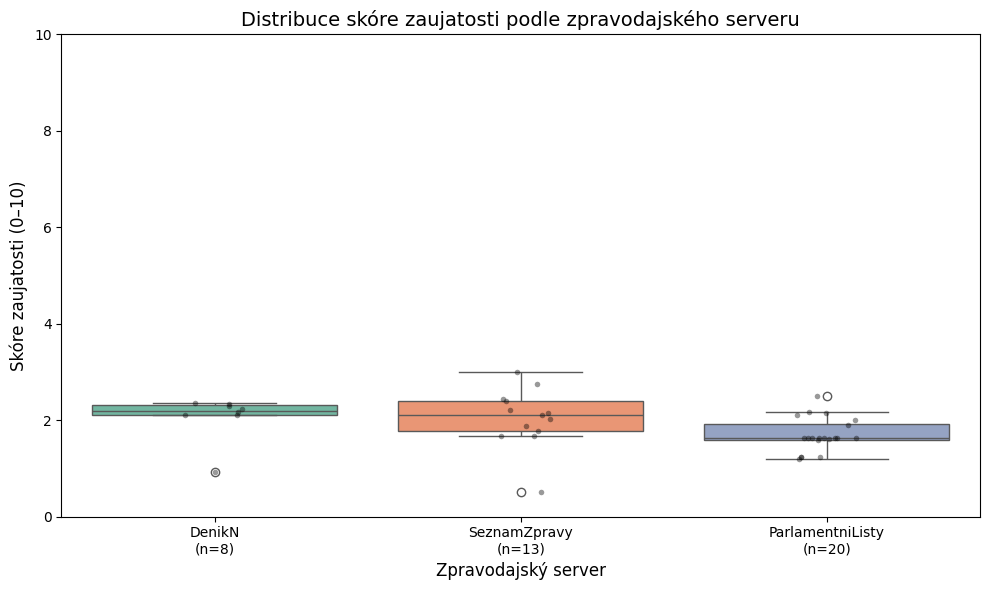

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'all_outlets_df' in locals() and 'refined_bias_corpus_score' in all_outlets_df.columns:

    # Pořadí zdrojů podle mediánu (od nejvíce po nejméně subjektivní)
    source_order = (
        all_outlets_df.groupby('source')['refined_bias_corpus_score']
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    sns.boxplot(
        data=all_outlets_df,
        x='source', y='refined_bias_corpus_score',
        order=source_order, palette='Set2', ax=ax
    )
    sns.stripplot(
        data=all_outlets_df,
        x='source', y='refined_bias_corpus_score',
        order=source_order, color='black', alpha=0.4, size=4, ax=ax
    )

    # Přidáme počet článků pod každý label
    xtick_labels = [
        f"{s}\n(n={len(all_outlets_df[all_outlets_df['source'] == s])})"
        for s in source_order
    ]
    ax.set_xticklabels(xtick_labels)

    ax.set_title('Distribuce skóre zaujatosti podle zpravodajského serveru', fontsize=14)
    ax.set_xlabel('Zpravodajský server', fontsize=12)
    ax.set_ylabel('Skóre zaujatosti (0–10)', fontsize=12)
    ax.set_ylim(0, 10)

    plt.tight_layout()
    plt.show()
else:
    print("Chybí data pro vizualizaci. Spusťte nejprve buňku 46.")

In [27]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

if 'articles_df' in locals() and 'subjectivity_index' in articles_df.columns and 'sentiment_label' in articles_df.columns:

    # Convert sentiment label ("1 star" … "5 stars") to a numeric 1–5 score
    def label_to_numeric(label):
        try:
            return int(str(label).split()[0])
        except (ValueError, IndexError):
            return None

    plot_df = articles_df.copy()
    plot_df['sentiment_numeric'] = plot_df['sentiment_label'].apply(label_to_numeric)

    # Use best available subjectivity score
    subjectivity_col = 'refined_bias_corpus_score' if 'refined_bias_corpus_score' in plot_df.columns else \
                       'refined_bias_score'         if 'refined_bias_score'         in plot_df.columns else \
                       'subjectivity_index'

    # Build hover text
    if 'top_keywords' in plot_df.columns:
        plot_df['hover_keywords'] = plot_df['top_keywords']
    else:
        plot_df['hover_keywords'] = ''

    plot_df = plot_df.dropna(subset=[subjectivity_col, 'sentiment_numeric'])

    x_min = plot_df[subjectivity_col].min()
    x_max = plot_df[subjectivity_col].max()

    fig = px.scatter(
        plot_df,
        x=subjectivity_col,
        y='sentiment_numeric',
        hover_name='title',
        hover_data={'hover_keywords': True, subjectivity_col: ':.3f', 'sentiment_numeric': True},
        color='sentiment_numeric',
        color_continuous_scale='RdYlGn',
        size_max=14,
        labels={
            subjectivity_col: 'Index subjektivity',
            'sentiment_numeric': 'Sentiment (1 = neg., 5 = poz.)',
            'hover_keywords': 'Klíčová slova',
        },
        title='Subjektivita vs. Sentiment článků (najeďte myší pro detail)',
    )

    fig.update_traces(
        marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')),
        selector=dict(mode='markers'),
    )

    subjectivity_explanation = (
        "<b>Index subjektivity</b> měří poměr<br>"
        "popisných slov (přídavná jména +<br>"
        "příslovce) k faktickým slovům<br>"
        "(podstatná jména + slovesa).<br>"
        "<b>Nízká hodnota</b> → objektivní styl<br>"
        "<b>Vysoká hodnota</b> → subjektivní styl<br>"
        "<br>"
        "<b>Sentiment</b> je detekován modelem<br>"
        "BERT (nlptown) na škále 1–5 hvězdiček.<br>"
        "<b>1 hvězdička</b> → velmi negativní tón<br>"
        "<b>5 hvězdiček</b> → velmi pozitivní tón"
    )

    fig.update_layout(
        xaxis_title='Index subjektivity  ◀ objektivní · subjektivní ▶',
        yaxis_title='▲ pozitivní  ·  Sentiment (1–5 hvězdiček)  ·  negativní ▼',
        yaxis=dict(tickmode='linear', tick0=1, dtick=1, range=[0.5, 5.5]),
        coloraxis_colorbar=dict(title='Sentiment'),
        hovermode='closest',
        height=580,
        annotations=[
            # Explanation box
            dict(
                text=subjectivity_explanation,
                xref='paper', yref='paper',
                x=1.18, y=0.5,
                showarrow=False,
                align='left',
                bgcolor='rgba(240,248,255,0.92)',
                bordercolor='steelblue',
                borderwidth=1,
                borderpad=8,
                font=dict(size=11),
            ),
            # X-axis low label
            dict(
                text='Objektivní',
                xref='x', yref='paper',
                x=x_min, y=-0.14,
                showarrow=False,
                font=dict(size=10, color='steelblue'),
                align='center',
            ),
            # X-axis high label
            dict(
                text='Subjektivní',
                xref='x', yref='paper',
                x=x_max, y=-0.14,
                showarrow=False,
                font=dict(size=10, color='firebrick'),
                align='center',
            ),
            # Y-axis low label (1 = negative)
            dict(
                text='Negativní',
                xref='paper', yref='y',
                x=-0.13, y=1,
                showarrow=False,
                font=dict(size=10, color='firebrick'),
                align='center',
            ),
            # Y-axis high label (5 = positive)
            dict(
                text='Pozitivní',
                xref='paper', yref='y',
                x=-0.13, y=5,
                showarrow=False,
                font=dict(size=10, color='green'),
                align='center',
            ),
        ],
        margin=dict(b=80, l=100, r=260),
    )

    fig.show()
else:
    print("Chybí potřebné sloupce (subjectivity_index, sentiment_label). Spusťte nejprve buňky 28 a 30.")


### 5. Dashboarding — Interaktivní vizualizace (Plotly)

Scatter plot **Subjektivita vs. Sentiment** — každý bod je jeden článek. Najeďte myší pro zobrazení titulku a klíčových slov.

In [28]:
import plotly.express as px
import pandas as pd

if 'articles_df' in locals() and 'subjectivity_index' in articles_df.columns and 'sentiment_label' in articles_df.columns:

    def label_to_numeric(label):
        try:
            return int(str(label).split()[0])
        except (ValueError, IndexError):
            return None

    plot_df = articles_df.copy()
    plot_df['sentiment_numeric'] = plot_df['sentiment_label'].apply(label_to_numeric)

    subjectivity_col = 'refined_bias_corpus_score' if 'refined_bias_corpus_score' in plot_df.columns else \
                       'refined_bias_score'         if 'refined_bias_score'         in plot_df.columns else \
                       'subjectivity_index'

    plot_df['hover_keywords'] = plot_df['top_keywords'] if 'top_keywords' in plot_df.columns else ''
    plot_df = plot_df.dropna(subset=[subjectivity_col, 'sentiment_numeric'])

    x_min = plot_df[subjectivity_col].min()
    x_max = plot_df[subjectivity_col].max()

    fig = px.scatter(
        plot_df,
        x=subjectivity_col,
        y='sentiment_numeric',
        hover_name='title',
        hover_data={'hover_keywords': True, subjectivity_col: ':.3f', 'sentiment_numeric': True},
        color='sentiment_numeric',
        color_continuous_scale='RdYlGn',
        labels={
            subjectivity_col: 'Index subjektivity',
            'sentiment_numeric': 'Sentiment (1–5 hvězdiček)',
            'hover_keywords': 'Klíčová slova',
        },
        title='Subjektivita vs. Sentiment článků (najeďte myší pro detail)',
    )

    fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))

    fig.update_layout(
        xaxis_title='Index subjektivity  ◀ objektivní · subjektivní ▶',
        yaxis_title='Sentiment (1–5 hvězdiček)',
        yaxis=dict(tickmode='linear', tick0=1, dtick=1, range=[0.5, 5.5]),
        coloraxis_colorbar=dict(title='Sentiment'),
        hovermode='closest',
        height=720,
        # Large left margin so Y labels aren't clipped; large bottom for explanation box
        margin=dict(t=60, b=240, l=110, r=80),
        annotations=[
            # X-axis endpoint labels
            dict(text='Objektivní', xref='x', yref='paper',
                 x=x_min, y=-0.20, showarrow=False,
                 font=dict(size=10, color='steelblue'), align='center'),
            dict(text='Subjektivní', xref='x', yref='paper',
                 x=x_max, y=-0.20, showarrow=False,
                 font=dict(size=10, color='firebrick'), align='center'),
            # Y-axis endpoint labels — placed just inside the left margin
            dict(text='Pozitivní ▶', xref='paper', yref='y',
                 x=-0.08, y=5, showarrow=False,
                 font=dict(size=10, color='green'), align='right', xanchor='right'),
            dict(text='Negativní ▶', xref='paper', yref='y',
                 x=-0.08, y=1, showarrow=False,
                 font=dict(size=10, color='firebrick'), align='right', xanchor='right'),
            # Explanation box — two lines, centered below the chart
            dict(
                text=(
                    "<b>Index subjektivity:</b> poměr popisných slov (přídavná jména + příslovce) "
                    "k faktickým slovům (podstatná jména + slovesa). Nízká hodnota = objektivní, vysoká = subjektivní.<br>"
                    "<b>Sentiment:</b> detekován modelem BERT (nlptown) na škále 1–5 hvězdiček "
                    "(1 hvězdička = velmi negativní tón, 5 hvězdiček = velmi pozitivní tón)."
                ),
                xref='paper', yref='paper',
                x=0.5, y=-0.36,
                showarrow=False,
                align='center',
                bgcolor='rgba(240,248,255,0.95)',
                bordercolor='steelblue',
                borderwidth=1,
                borderpad=10,
                font=dict(size=11),
            ),
        ],
    )

    fig.show()
else:
    print("Chybí potřebné sloupce (subjectivity_index, sentiment_label). Spusťte nejprve buňky 28 a 30.")


### 20. Mood-aware recommendation over vector search

Finální krok projektu: uživatel zadá svoji aktuální náladu nebo tón, který chce číst, a notebook doporučí články z vektorové databáze.
Přístup je hybridní: vektorové vyhledání vrátí kandidáty a sentiment + subjektivita se použijí pro filtrování a reranking.


In [29]:
import os
import subprocess
import sys
from pathlib import Path

for package in ('qdrant-client', 'python-dotenv'):
    try:
        if package == 'qdrant-client':
            import qdrant_client  # noqa: F401
        else:
            import dotenv  # noqa: F401
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

try:
    from dotenv import load_dotenv
except ImportError:
    def load_dotenv(path='.env'):
        env_path = Path(path)
        if not env_path.exists():
            return False
        for raw_line in env_path.read_text(encoding='utf-8').splitlines():
            line = raw_line.strip()
            if not line or line.startswith('#') or '=' not in line:
                continue
            key, value = line.split('=', 1)
            os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))
        return True

loaded = load_dotenv('.env')

print('Načteno .env:', loaded and os.path.exists('.env'))
print('QDRANT_URL:', os.environ.get('QDRANT_URL', 'nenastaveno'))
print('LLM_BASE_URL:', os.environ.get('LLM_BASE_URL', 'nenastaveno'))



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


ModuleNotFoundError: No module named 'dotenv'

In [ ]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import uuid
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence

import numpy as np
import pandas as pd
import requests
from sklearn.feature_extraction.text import HashingVectorizer

SYNC_STATE_FILE = "article_vector_sync.json"
DEFAULT_COLLECTION_NAME = "news_articles"
DEFAULT_EMBEDDING_MODEL = "intfloat/multilingual-e5-small"
DEFAULT_LLM_MODEL = "openrouter/auto"

TONE_KEYWORDS = {
    "shocking", "reveal", "revealing", "dramatic", "controversial", "explosive",
    "investigative", "surprising", "surprise", "odhalujici", "odhalující",
    "sokujici", "šokující", "prekvapive", "překvapivé", "kontroverzni", "kontroverzní",
}

LOW_ENERGY_KEYWORDS = {
    "sad", "tired", "down", "anxious", "stress", "stressed", "burned out", "depressed",
    "unhappy", "smutny", "smutná", "smutný", "unaveny", "unavená", "unavený",
    "vycerpany", "vyčerpaný", "vyčerpaná", "ve stresu", "uzkost", "úzkost",
}


def _safe_float(value: Any, default: float = 0.0) -> float:
    if value is None:
        return default
    if isinstance(value, (int, float)):
        try:
            if math.isnan(value):
                return default
        except TypeError:
            pass
        return float(value)
    try:
        parsed = float(value)
        if math.isnan(parsed):
            return default
        return parsed
    except (TypeError, ValueError):
        return default


def _safe_text(value: Any) -> str:
    if value is None:
        return ""
    if isinstance(value, str):
        return value.strip()
    if isinstance(value, (list, tuple)):
        return ", ".join(str(item).strip() for item in value if str(item).strip())
    try:
        if pd.isna(value):
            return ""
    except Exception:
        pass
    return str(value).strip()


def _parse_sentiment_numeric(row: pd.Series) -> float:
    if "sentiment_numeric" in row and not pd.isna(row["sentiment_numeric"]):
        return _safe_float(row["sentiment_numeric"], 3.0)
    label = _safe_text(row.get("sentiment_label"))
    match = re.search(r"([1-5])", label)
    return float(match.group(1)) if match else 3.0


def _best_subjectivity_column(df: pd.DataFrame) -> Optional[str]:
    for column in ("refined_bias_corpus_score", "refined_bias_score", "subjectivity_index"):
        if column in df.columns:
            return column
    return None


def _keywords_from_row(row: pd.Series) -> List[str]:
    for column in ("top_keywords_refined", "top_keywords", "hover_keywords"):
        value = _safe_text(row.get(column))
        if value:
            return [item.strip() for item in value.split(",") if item.strip()]
    return []


def _normalize_subjectivity(value: float) -> float:
    if value <= 0:
        return 0.0
    if value <= 3:
        return min(value / 3.0, 1.0)
    return min(value / 10.0, 1.0)


def _keyword_overlap(query: str, keywords: Sequence[str]) -> float:
    query_terms = {term for term in re.findall(r"\w+", query.lower()) if len(term) > 2}
    keyword_terms = {
        term
        for keyword in keywords
        for term in re.findall(r"\w+", keyword.lower())
        if len(term) > 2
    }
    if not query_terms or not keyword_terms:
        return 0.0
    return len(query_terms & keyword_terms) / len(query_terms)


def select_corpus(articles_df: Optional[pd.DataFrame] = None, all_outlets_df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    if all_outlets_df is not None and not all_outlets_df.empty:
        return all_outlets_df.copy()
    if articles_df is not None and not articles_df.empty:
        return articles_df.copy()
    raise ValueError("No article dataframe is available for recommendation.")


def prepare_articles_for_indexing(df: pd.DataFrame) -> List[Dict[str, Any]]:
    if df.empty:
        return []

    subjectivity_column = _best_subjectivity_column(df)
    records: List[Dict[str, Any]] = []
    for _, row in df.iterrows():
        url = _safe_text(row.get("url"))
        title = _safe_text(row.get("title"))
        text = _safe_text(row.get("text"))
        if not url or not title or not text:
            continue

        cleaned_text = _safe_text(row.get("cleaned_text"))
        lemmatized_text = _safe_text(row.get("lemmatized_text"))
        source = _safe_text(row.get("source")) or "SeznamZpravy"
        keywords = _keywords_from_row(row)
        sentiment_numeric = _parse_sentiment_numeric(row)
        subjectivity_value = _safe_float(row.get(subjectivity_column), 0.0) if subjectivity_column else 0.0
        bias_score = _safe_float(row.get("refined_bias_corpus_score"), _safe_float(row.get("refined_bias_score"), 0.0))
        published_at = _safe_text(row.get("publish_date"))

        retrieval_text = "\\n".join(
            part for part in [
                f"title: {title}",
                f"source: {source}",
                f"keywords: {', '.join(keywords)}" if keywords else "",
                f"cleaned: {cleaned_text[:500]}" if cleaned_text else "",
                f"lemmatized: {lemmatized_text[:500]}" if lemmatized_text else "",
                f"article: {text[:1400]}",
            ] if part
        )

        content_hash = hashlib.sha256(
            "||".join([
                url, title, text, ",".join(keywords), str(sentiment_numeric), str(subjectivity_value), str(bias_score)
            ]).encode("utf-8")
        ).hexdigest()

        records.append({
            "id": str(uuid.uuid5(uuid.NAMESPACE_URL, url)),
            "url": url,
            "title": title,
            "source": source,
            "publish_date": published_at,
            "text": text,
            "cleaned_text": cleaned_text,
            "lemmatized_text": lemmatized_text,
            "keywords": keywords,
            "sentiment_label": _safe_text(row.get("sentiment_label")),
            "sentiment_numeric": sentiment_numeric,
            "sentiment_score": _safe_float(row.get("sentiment_score"), 0.0),
            "subjectivity_score": subjectivity_value,
            "bias_score": bias_score,
            "retrieval_text": retrieval_text,
            "content_hash": content_hash,
        })
    return records


def load_sync_state(sync_state_path: str = SYNC_STATE_FILE) -> Dict[str, str]:
    path = Path(sync_state_path)
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except json.JSONDecodeError:
        return {}


def save_sync_state(state: Dict[str, str], sync_state_path: str = SYNC_STATE_FILE) -> None:
    Path(sync_state_path).write_text(json.dumps(state, ensure_ascii=False, indent=2), encoding="utf-8")


@dataclass
class QdrantConfig:
    url: str
    collection_name: str = DEFAULT_COLLECTION_NAME
    api_key: Optional[str] = None
    prefer_grpc: bool = False


@dataclass
class LLMConfig:
    base_url: str
    model: str = DEFAULT_LLM_MODEL
    api_key: Optional[str] = None
    timeout_seconds: int = 30


@dataclass
class IntentProfile:
    intent_type: str
    search_query: str
    target_sentiment: float
    target_subjectivity: float
    boost_positive: bool
    allow_intense: bool
    reason: str
    requested_keywords: List[str] = field(default_factory=list)
    mood_signals: List[str] = field(default_factory=list)


class TransformerEmbeddingProvider:
    def __init__(self, model_name: str = DEFAULT_EMBEDDING_MODEL, device: Optional[str] = None):
        self.model_name = model_name
        self.device = device
        self._tokenizer = None
        self._model = None
        self._torch = None
        self._fallback_vectorizer = HashingVectorizer(
            n_features=512,
            alternate_sign=False,
            norm=None,
        )
        self.using_fallback = False

    def _load(self) -> None:
        if self._model is not None or self.using_fallback:
            return
        try:
            from transformers import AutoModel, AutoTokenizer
            import torch
            self._torch = torch
            self._tokenizer = AutoTokenizer.from_pretrained(self.model_name, local_files_only=True)
            self._model = AutoModel.from_pretrained(self.model_name, local_files_only=True)
            if self.device:
                self._model = self._model.to(self.device)
            self._model.eval()
        except Exception as exc:
            self.using_fallback = True
            print(f'Embedding fallback aktivní: {exc}')

    def _mean_pool(self, model_output: Any, attention_mask: Any) -> Any:
        token_embeddings = model_output[0]
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        return (token_embeddings * input_mask_expanded).sum(1) / input_mask_expanded.sum(1).clamp(min=1e-9)

    def _fallback_embed(self, texts: Sequence[str], prefix: str) -> List[List[float]]:
        matrix = self._fallback_vectorizer.transform([f"{prefix}{text}" for text in texts]).toarray().astype(float)
        norms = np.linalg.norm(matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return (matrix / norms).tolist()

    def _embed(self, texts: Sequence[str], prefix: str) -> List[List[float]]:
        self._load()
        if self.using_fallback:
            return self._fallback_embed(texts, prefix)
        encoded = self._tokenizer(
            [f"{prefix}{text}" for text in texts],
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt",
        )
        if self.device:
            encoded = {key: value.to(self.device) for key, value in encoded.items()}
        with self._torch.no_grad():
            model_output = self._model(**encoded)
        embeddings = self._mean_pool(model_output, encoded["attention_mask"])
        normalized = self._torch.nn.functional.normalize(embeddings, p=2, dim=1)
        return normalized.cpu().numpy().tolist()

    def embed_documents(self, texts: Sequence[str]) -> List[List[float]]:
        return self._embed(texts, prefix="passage: ")

    def embed_query(self, text: str) -> List[float]:
        return self._embed([text], prefix="query: ")[0]


class OpenAICompatibleLLM:
    def __init__(self, config: LLMConfig):
        self.config = config

    def _chat(self, system_prompt: str, user_prompt: str) -> str:
        headers = {"Content-Type": "application/json"}
        if self.config.api_key:
            headers["Authorization"] = f"Bearer {self.config.api_key}"
        payload = {
            "model": self.config.model,
            "temperature": 0.1,
            "response_format": {"type": "json_object"},
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
        }
        response = requests.post(
            f"{self.config.base_url.rstrip('/')}/chat/completions",
            headers=headers,
            json=payload,
            timeout=self.config.timeout_seconds,
        )
        response.raise_for_status()
        data = response.json()
        return data["choices"][0]["message"]["content"]

    def classify_intent(self, prompt: str) -> Optional[IntentProfile]:
        system_prompt = (
            "You classify user reading requests into recommendation intents. "
            "Return JSON with keys: intent_type, search_query, target_sentiment, "
            "target_subjectivity, boost_positive, allow_intense, reason, requested_keywords, mood_signals. "
            "intent_type must be tone_seeking or state_seeking."
        )
        try:
            data = json.loads(self._chat(system_prompt, prompt))
            return IntentProfile(
                intent_type=data["intent_type"],
                search_query=data.get("search_query") or prompt,
                target_sentiment=_safe_float(data.get("target_sentiment"), 3.0),
                target_subjectivity=_safe_float(data.get("target_subjectivity"), 0.5),
                boost_positive=bool(data.get("boost_positive")),
                allow_intense=bool(data.get("allow_intense", True)),
                reason=_safe_text(data.get("reason")) or "LLM classification",
                requested_keywords=list(data.get("requested_keywords") or []),
                mood_signals=list(data.get("mood_signals") or []),
            )
        except Exception:
            return None

    def rerank_candidates(self, prompt: str, intent: IntentProfile, candidates: Sequence[Dict[str, Any]], top_n: int) -> Dict[str, Dict[str, Any]]:
        system_prompt = (
            "You rerank news article candidates for a reader. "
            "Return JSON with key picks: an array of objects with url, boost, reason. "
            "boost must be between -0.2 and 0.2."
        )
        compact_candidates = [{
            "url": candidate["url"],
            "title": candidate["title"],
            "source": candidate["source"],
            "keywords": candidate.get("keywords", []),
            "sentiment_numeric": candidate.get("sentiment_numeric"),
            "subjectivity_score": candidate.get("subjectivity_score"),
            "bias_score": candidate.get("bias_score"),
        } for candidate in list(candidates)[:top_n]]
        try:
            data = json.loads(self._chat(system_prompt, json.dumps({
                "prompt": prompt,
                "intent": intent.__dict__,
                "candidates": compact_candidates,
            }, ensure_ascii=False)))
            picks = {}
            for pick in data.get("picks", []):
                url = _safe_text(pick.get("url"))
                if url:
                    picks[url] = {
                        "boost": max(-0.2, min(0.2, _safe_float(pick.get("boost"), 0.0))),
                        "reason": _safe_text(pick.get("reason")),
                    }
            return picks
        except Exception:
            return {}


def classify_user_request(prompt: str, llm_client: Optional[OpenAICompatibleLLM] = None) -> IntentProfile:
    if llm_client is not None:
        profile = llm_client.classify_intent(prompt)
        if profile is not None:
            return profile

    lowered = prompt.lower()
    matched_tone = sorted(keyword for keyword in TONE_KEYWORDS if keyword in lowered)
    matched_state = sorted(keyword for keyword in LOW_ENERGY_KEYWORDS if keyword in lowered)

    if matched_state and not matched_tone:
        return IntentProfile(
            intent_type="state_seeking",
            search_query=prompt,
            target_sentiment=4.5,
            target_subjectivity=0.35,
            boost_positive=True,
            allow_intense=False,
            reason="Heuristic mood-repair profile based on low-energy words.",
            mood_signals=matched_state,
        )

    return IntentProfile(
        intent_type="tone_seeking",
        search_query=prompt,
        target_sentiment=3.2,
        target_subjectivity=0.75,
        boost_positive=False,
        allow_intense=True,
        reason="Heuristic tone-matching profile based on requested article tone.",
        requested_keywords=matched_tone,
        mood_signals=matched_state,
    )


class QdrantArticleIndex:
    def __init__(self, config: QdrantConfig):
        self.config = config
        self._client = None
        self._models = None

    def _load(self) -> None:
        if self._client is not None:
            return
        from qdrant_client import QdrantClient
        from qdrant_client.http import models
        self._models = models
        self._client = QdrantClient(url=self.config.url, api_key=self.config.api_key, prefer_grpc=self.config.prefer_grpc)

    def ensure_collection(self, vector_size: int, sync_state_path: str = SYNC_STATE_FILE) -> None:
        self._load()
        existing = {collection.name for collection in self._client.get_collections().collections}
        if self.config.collection_name in existing:
            info = self._client.get_collection(self.config.collection_name)
            current_vectors = info.config.params.vectors
            current_size = getattr(current_vectors, "size", None)
            if current_size != vector_size:
                print(f'Resetuji kolekci {self.config.collection_name}: dimenze {current_size} -> {vector_size}.')
                self._client.delete_collection(self.config.collection_name)
                if Path(sync_state_path).exists():
                    Path(sync_state_path).unlink()
            else:
                return
        self._client.create_collection(
            collection_name=self.config.collection_name,
            vectors_config=self._models.VectorParams(size=vector_size, distance=self._models.Distance.COSINE),
        )

    def upsert_records(self, records: Sequence[Dict[str, Any]], embedding_provider: TransformerEmbeddingProvider, sync_state_path: str = SYNC_STATE_FILE) -> Dict[str, int]:
        if not records:
            return {"indexed": 0, "skipped": 0}

        probe_vector = embedding_provider.embed_documents([records[0]["retrieval_text"]])[0]
        self.ensure_collection(len(probe_vector), sync_state_path=sync_state_path)

        sync_state = load_sync_state(sync_state_path)
        changed_records = [record for record in records if sync_state.get(record["url"]) != record["content_hash"]]
        skipped = len(records) - len(changed_records)
        if not changed_records:
            return {"indexed": 0, "skipped": skipped}

        vectors = embedding_provider.embed_documents([record["retrieval_text"] for record in changed_records])
        sync_state = load_sync_state(sync_state_path)
        points = []
        for record, vector in zip(changed_records, vectors):
            payload = {key: value for key, value in record.items() if key not in {"id", "retrieval_text", "content_hash"}}
            points.append(self._models.PointStruct(id=record["id"], vector=vector, payload=payload))
            sync_state[record["url"]] = record["content_hash"]

        self._client.upsert(collection_name=self.config.collection_name, points=points)
        save_sync_state(sync_state, sync_state_path)
        return {"indexed": len(changed_records), "skipped": skipped}

    def _build_filter(self, intent: IntentProfile) -> Optional[Any]:
        self._load()
        conditions = []
        if intent.boost_positive:
            conditions.append(self._models.FieldCondition(key="sentiment_numeric", range=self._models.Range(gte=max(4.0, intent.target_sentiment - 0.25))))
        if not intent.allow_intense:
            conditions.append(self._models.FieldCondition(key="subjectivity_score", range=self._models.Range(lte=1.6)))
        if not conditions:
            return None
        return self._models.Filter(must=conditions)

    def query(self, prompt: str, intent: IntentProfile, embedding_provider: TransformerEmbeddingProvider, limit: int = 15) -> List[Dict[str, Any]]:
        self._load()
        vector = embedding_provider.embed_query(intent.search_query or prompt)
        query_filter = self._build_filter(intent)

        if hasattr(self._client, "search"):
            hits = self._client.search(
                collection_name=self.config.collection_name,
                query_vector=vector,
                query_filter=query_filter,
                limit=limit,
                with_payload=True,
            )
        else:
            response = self._client.query_points(
                collection_name=self.config.collection_name,
                query=vector,
                query_filter=query_filter,
                limit=limit,
                with_payload=True,
            )
            hits = response.points if hasattr(response, "points") else response

        candidates = []
        for hit in hits:
            payload = dict(hit.payload or {})
            payload["vector_score"] = float(getattr(hit, "score", 0.0))
            candidates.append(payload)
        return candidates


def retrieve_candidate_articles(prompt: str, intent_profile: IntentProfile, article_index: QdrantArticleIndex, embedding_provider: TransformerEmbeddingProvider, top_k: int = 15) -> List[Dict[str, Any]]:
    return article_index.query(prompt, intent_profile, embedding_provider, limit=top_k)


def rerank_articles(prompt: str, intent_profile: IntentProfile, candidates: Sequence[Dict[str, Any]], llm_client: Optional[OpenAICompatibleLLM] = None, top_n: int = 5) -> List[Dict[str, Any]]:
    ranked = []
    llm_adjustments = llm_client.rerank_candidates(prompt, intent_profile, candidates, top_n=8) if llm_client else {}
    for candidate in candidates:
        vector_score = _safe_float(candidate.get("vector_score"), 0.0)
        sentiment_numeric = _safe_float(candidate.get("sentiment_numeric"), 3.0)
        subjectivity_score = _normalize_subjectivity(_safe_float(candidate.get("subjectivity_score"), 0.0))
        keyword_score = _keyword_overlap(prompt, candidate.get("keywords") or [])
        sentiment_fit = max(0.0, 1.0 - abs(sentiment_numeric - intent_profile.target_sentiment) / 4.0)
        subjectivity_fit = max(0.0, 1.0 - abs(subjectivity_score - intent_profile.target_subjectivity))

        if intent_profile.intent_type == "state_seeking":
            rule_score = 0.45 * vector_score + 0.30 * sentiment_fit + 0.15 * subjectivity_fit + 0.10 * keyword_score
        else:
            rule_score = 0.55 * vector_score + 0.15 * sentiment_fit + 0.20 * subjectivity_fit + 0.10 * keyword_score

        llm_boost = 0.0
        llm_reason = ""
        adjustment = llm_adjustments.get(candidate.get("url", ""))
        if adjustment:
            llm_boost = _safe_float(adjustment.get("boost"), 0.0)
            llm_reason = _safe_text(adjustment.get("reason"))

        ranked_candidate = dict(candidate)
        ranked_candidate["final_score"] = round(rule_score + llm_boost, 4)
        reason_parts = [
            f"semantic={vector_score:.3f}",
            f"sentiment_fit={sentiment_fit:.3f}",
            f"subjectivity_fit={subjectivity_fit:.3f}",
        ]
        if keyword_score:
            reason_parts.append(f"keywords={keyword_score:.3f}")
        if llm_reason:
            reason_parts.append(f"llm={llm_reason}")
        ranked_candidate["recommendation_reason"] = "; ".join(reason_parts)
        ranked.append(ranked_candidate)

    ranked.sort(key=lambda item: item["final_score"], reverse=True)
    return ranked[:top_n]


class MoodAwareArticleRecommender:
    def __init__(self, article_index: QdrantArticleIndex, embedding_provider: TransformerEmbeddingProvider, llm_client: Optional[OpenAICompatibleLLM] = None, sync_state_path: str = SYNC_STATE_FILE):
        self.article_index = article_index
        self.embedding_provider = embedding_provider
        self.llm_client = llm_client
        self.sync_state_path = sync_state_path

    def index_dataframe(self, df: pd.DataFrame) -> Dict[str, int]:
        return self.article_index.upsert_records(prepare_articles_for_indexing(df), self.embedding_provider, self.sync_state_path)

    def recommend_articles_for_mood(self, prompt: str, top_n: int = 5, candidate_pool: int = 15) -> List[Dict[str, Any]]:
        intent = classify_user_request(prompt, llm_client=self.llm_client)
        candidates = retrieve_candidate_articles(prompt, intent, self.article_index, self.embedding_provider, top_k=candidate_pool)
        recommendations = rerank_articles(prompt, intent, candidates, llm_client=self.llm_client, top_n=top_n)
        for recommendation in recommendations:
            recommendation["intent_type"] = intent.intent_type
            recommendation["intent_reason"] = intent.reason
        return recommendations


def build_llm_client_from_env(api_key_env: str = "OPENROUTER_API_KEY", base_url_env: str = "LLM_BASE_URL", model_env: str = "LLM_MODEL") -> Optional[OpenAICompatibleLLM]:
    base_url = os.environ.get(base_url_env)
    if not base_url:
        return None
    return OpenAICompatibleLLM(LLMConfig(
        base_url=base_url,
        api_key=os.environ.get(api_key_env),
        model=os.environ.get(model_env, DEFAULT_LLM_MODEL),
    ))


In [ ]:
QDRANT_URL = os.environ.get('QDRANT_URL')
QDRANT_API_KEY = os.environ.get('QDRANT_API_KEY')
QDRANT_COLLECTION = os.environ.get('QDRANT_COLLECTION', 'news_articles')
LOCAL_EMBEDDING_MODEL = 'models/intfloat-multilingual-e5-small'
ENV_EMBEDDING_MODEL = os.environ.get('EMBEDDING_MODEL')
EMBEDDING_MODEL = (
    ENV_EMBEDDING_MODEL if ENV_EMBEDDING_MODEL and os.path.isdir(ENV_EMBEDDING_MODEL)
    else LOCAL_EMBEDDING_MODEL if os.path.isdir(LOCAL_EMBEDDING_MODEL)
    else ENV_EMBEDDING_MODEL or 'intfloat/multilingual-e5-small'
)

if not QDRANT_URL:
    print('Vytvořte .env podle .env.example a nastavte minimálně QDRANT_URL.')
else:
    recommendation_df = select_corpus(
        articles_df if 'articles_df' in locals() else None,
        all_outlets_df if 'all_outlets_df' in locals() else None,
    )
    print(f'Pro doporučování používám {len(recommendation_df)} článků.')

    embedding_provider = TransformerEmbeddingProvider(model_name=EMBEDDING_MODEL)
    article_index = QdrantArticleIndex(QdrantConfig(
        url=QDRANT_URL,
        api_key=QDRANT_API_KEY,
        collection_name=QDRANT_COLLECTION,
    ))
    llm_client = build_llm_client_from_env()
    recommender = MoodAwareArticleRecommender(
        article_index=article_index,
        embedding_provider=embedding_provider,
        llm_client=llm_client,
    )

    sync_stats = recommender.index_dataframe(recommendation_df)
    print('Indexing hotovo:', sync_stats)


In [ ]:
from IPython.display import display
import pandas as pd

user_mood_prompt = 'I want something shocking and revealing.'

if 'recommender' not in locals():
    print('Spusťte nejprve předchozí buňky pro načtení .env a indexaci článků.')
else:
    recommendations = recommender.recommend_articles_for_mood(user_mood_prompt, top_n=5)
    if recommendations:
        display(pd.DataFrame(recommendations)[[
            'title', 'source', 'sentiment_numeric', 'subjectivity_score',
            'bias_score', 'keywords', 'recommendation_reason', 'url'
        ]])
    else:
        print('Nebyl vrácen žádný doporučený článek. Zkontrolujte indexaci nebo prompt.')
